# 07 — Scenario Analysis (Counterfactual + SHAP)

Двухэтапный анализ продуктовых метрик для 6 пар (app, target):
1. **ДИАГНОЗ (SHAP):** какие operational метрики тащат прогноз вниз/вверх на baseline (день T=86)?
2. **ЛЕЧЕНИЕ (Scenario Analysis):** counterfactual «что произойдёт если улучшить эти метрики до индустриальных бенчмарков» — 42 сценария с MC trajectory + BCa CI.

**Главный артефакт:** `results/scenario_recommendations.csv` — ранжированные приоритеты per product (диагноз → лечение → ROI).

## 0. Контекст

**Что отличает от существующего `src/scenario_analysis.py`:**
1. **Baseline = реальное X[T=86]** (не median(X_train)) — внутри train manifold, curse of dim не активируется на 6 парах.
2. **Возмущения только на operational features** (3-6 фич, не 15) → effective dim возмущения = 3-6.
3. **MC trajectory вместо point estimate**: 1000 симуляций × recursive 14-day forecast (lag-фичи рекурсивные, как в 06b).
4. **SHAP перед сценариями** — диагноз → лечение → рекомендация.

**Best models per pair (из 06b winners):**
- f1.stickiness → Ridge
- f1.dau → RandomForest
- f1.retention_d7 → LocalLinear
- f2.stickiness → Ridge
- f2.dau → NadarayaWatson
- f2.retention_d7 → NadarayaWatson

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

from src.feature_engineering import load_dataset
from src.kernel_regression import NadarayaWatsonRegressor, LocalLinearRegressor
from src.scenario_analysis import ScenarioAnalyzer  # переиспользуем готовый BCa (метод класса)


def bca_bootstrap_ci(data, alpha=0.05, n_bootstrap=2000, seed=42):
    """Тонкая обёртка над ScenarioAnalyzer.bca_bootstrap_ci (метод не использует self)."""
    return ScenarioAnalyzer.bca_bootstrap_ci(
        None, data, alpha=alpha, n_bootstrap=n_bootstrap, seed=seed,
    )
from notebooks._common import (
    APP_PALETTE, FIGSIZE_DEFAULT, FIGSIZE_WIDE,
    save_figure, theme_setup, app_label,
    build_xy,
)

theme_setup()
np.random.seed(42)

NOTEBOOK_SLUG = "07_scenarios"
APP_F1 = "com.labpixies.flood"
APP_F2 = "com.google.flood2"

# Configuration
TRAIN_END = 86            # последний train-день (как в 06b)
H_DEMO = 14               # горизонт траектории
N_BOOTSTRAP = 2000        # для BCa CI (как в src/scenario_analysis)
N_MC_SIMULATIONS = 1000   # MC симуляций per scenario
CI_LEVEL = 0.95
TARGET_LAGS = [1, 7]      # consistent с 06b
NOISE_PCT = 0.05          # 5% × std признака для гауссова шума на ops features

# Целевые значения для improvement-сценариев (benchmarks из индустриальные бенчмарки)
OPS_TARGETS_FIXED = {
    "crash_rate":                  0.02,   # Google Play threshold
    "crash_rate_ma7":              0.02,
    "retention_d7":                0.15,   # Mixpanel/Adapty 2024 для Puzzle
    "onboarding_completion_rate":  0.80,   # industry top-quartile
}
# session_duration variants — best_in_train * 1.3, вычисляются per pair

# 06b best-per-pair models (winner by RMSE из 06b summary)
BEST_MODELS_PER_PAIR = {
    ("f1", "stickiness"):   "Ridge",
    ("f1", "dau"):          "RandomForest",
    ("f1", "retention_d7"): "LocalLinear",
    ("f2", "stickiness"):   "Ridge",
    ("f2", "dau"):          "NadarayaWatson",
    ("f2", "retention_d7"): "NadarayaWatson",
}

print(f"Configuration: TRAIN_END={TRAIN_END}, H_DEMO={H_DEMO}, "
      f"N_MC_SIMULATIONS={N_MC_SIMULATIONS}, N_BOOTSTRAP={N_BOOTSTRAP}, "
      f"NOISE_PCT={NOISE_PCT}, TARGET_LAGS={TARGET_LAGS}")
print(f"Best models per pair: {BEST_MODELS_PER_PAIR}")


Configuration: TRAIN_END=86, H_DEMO=14, N_MC_SIMULATIONS=1000, N_BOOTSTRAP=2000, NOISE_PCT=0.05, TARGET_LAGS=[1, 7]
Best models per pair: {('f1', 'stickiness'): 'Ridge', ('f1', 'dau'): 'RandomForest', ('f1', 'retention_d7'): 'LocalLinear', ('f2', 'stickiness'): 'Ridge', ('f2', 'dau'): 'NadarayaWatson', ('f2', 'retention_d7'): 'NadarayaWatson'}


## 1. Загрузка данных + конфиги + sanity

In [2]:
df = load_dataset()
print(f"Dataset: {df.shape}")

FINAL_CONFIG = json.loads((ROOT / "results" / "final_config.json").read_text(encoding="utf-8"))
RECURSIVE_SUMMARY = pd.read_csv(ROOT / "results" / "forecast_validation_recursive_summary.csv")

TARGETS = ["stickiness", "dau", "retention_d7"]
PAIRS = [(APP_F1, t) for t in TARGETS] + [(APP_F2, t) for t in TARGETS]

# Sanity: best model в RECURSIVE_SUMMARY соответствует BEST_MODELS_PER_PAIR
for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    sub = RECURSIVE_SUMMARY[(RECURSIVE_SUMMARY["app"] == app_key) &
                             (RECURSIVE_SUMMARY["target"] == target)]
    assert len(sub) > 0, f"Missing recursive summary for {app_key}.{target}"
    best_in_summary = sub.loc[sub["RMSE"].idxmin()]["model"]
    expected = BEST_MODELS_PER_PAIR[(app_key, target)]
    if best_in_summary != expected:
        print(f"  WARN: {app_key}.{target} best in summary={best_in_summary}, "
              f"expected={expected}; используем expected как single source of truth")

print("All 6 pairs validated.")
print(f"\nOperational features per pair:")
for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    cfg = FINAL_CONFIG[app_key][target]
    ops = cfg.get("operational_features", [])
    print(f"  {app_key}.{target}: {len(ops)} ops = {ops}")


Dataset: (222, 60)
All 6 pairs validated.

Operational features per pair:
  f1.stickiness: 3 ops = ['crash_rate', 'median_session_duration', 'onboarding_completion_rate']
  f1.dau: 3 ops = ['crash_rate', 'median_session_duration', 'onboarding_completion_rate']
  f1.retention_d7: 3 ops = ['crash_rate', 'median_session_duration', 'onboarding_completion_rate']
  f2.stickiness: 6 ops = ['avg_session_duration', 'avg_session_duration_ma7', 'crash_rate', 'crash_rate_ma7', 'median_session_duration', 'onboarding_completion_rate']
  f2.dau: 6 ops = ['avg_session_duration', 'avg_session_duration_ma7', 'crash_rate', 'crash_rate_ma7', 'median_session_duration', 'onboarding_completion_rate']
  f2.retention_d7: 3 ops = ['avg_session_duration', 'crash_rate', 'onboarding_completion_rate']


## 2. Helper-функции

9 helpers определены ВНУТРИ ноутбука — research остаётся self-contained. Дублируют логику из 06b (recursive forecast, lag features) + добавляют сценарную специфику (baseline state, scenario taxonomy, MC trajectory, SHAP).

In [3]:
def _add_lag_features(df_app: pd.DataFrame, target: str,
                       lags=TARGET_LAGS) -> pd.DataFrame:
    """Adds target_lag<l> columns. ffill+bfill target before shift to keep
    history for sparse targets (e.g., retention_d7 with NaN gaps).
    """
    out = df_app.copy().sort_values("date").reset_index(drop=True)
    target_filled = out[target].ffill().bfill()
    for lag in lags:
        out[f"target_lag{lag}"] = target_filled.shift(lag)
    return out


def _build_extended_xy(train_df: pd.DataFrame, target: str, base_features: list,
                        train_medians: dict, lags=TARGET_LAGS):
    """Extended feature set [base + target_lag1 + target_lag7]. Drops first
    max(lags) rows where lag is NaN. Keeps row alignment between X and y via
    target.notna() filter (consistent with build_xy contract)."""
    df_with_lags = _add_lag_features(train_df, target, lags=lags)
    df_target_ok = df_with_lags[df_with_lags[target].notna()].copy()

    X_base, y_full, _ = build_xy(df_target_ok, target, base_features,
                                   train_medians=train_medians)

    lag_names = [f"target_lag{l}" for l in lags]
    lag_values = df_target_ok[lag_names].values

    X_extended = np.hstack([X_base, lag_values])
    mask = ~np.isnan(X_extended).any(axis=1)
    X_clean = X_extended[mask]
    y_clean = np.asarray(y_full)[mask]

    feature_names = list(base_features) + lag_names
    return X_clean, y_clean, feature_names


def _retune_bandwidth(model_class, X_sc, y, kernel,
                      h_grid=None, n_splits=5, random_state=42) -> float:
    """KFold CV bandwidth selection for NW/LocalLinear on extended feature set."""
    if h_grid is None:
        h_grid = np.logspace(-1.5, 1.0, 12)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    cv_rmse = np.full(len(h_grid), np.inf)
    for i, h in enumerate(h_grid):
        fold_rmse = []
        for tr_idx, vl_idx in kf.split(X_sc):
            try:
                with np.errstate(divide="ignore", invalid="ignore"):
                    m = model_class(kernel=kernel, bandwidth=float(h))
                    m.fit(X_sc[tr_idx], y[tr_idx])
                    pred = np.asarray(m.predict(X_sc[vl_idx]), dtype=float)
                    fold_rmse.append(float(np.sqrt(np.mean((y[vl_idx] - pred) ** 2))))
            except Exception:
                fold_rmse.append(np.inf)
        cv_rmse[i] = float(np.mean(fold_rmse))
    return float(h_grid[int(np.argmin(cv_rmse))])


In [4]:
def _train_scenario_model(app_id: str, target: str, model_name: str,
                            train_df: pd.DataFrame, final_config: dict) -> dict:
    """Trains one of 06b winners on extended feature set.

    Returns dict: model, model_name, scaler, feature_names, base_features,
                  X_train_raw, X_train_sc, y_train, bandwidth_used.
    """
    app_key = "f1" if app_id == APP_F1 else "f2"
    cfg = final_config[app_key][target]
    base_features = cfg["features"]
    medians = cfg["feature_train_medians"]

    X_raw, y, feature_names = _build_extended_xy(
        train_df, target, base_features, medians, lags=TARGET_LAGS
    )
    if len(X_raw) < 10:
        raise ValueError(f"Train too small for {app_key}.{target}/{model_name}")

    scaler = StandardScaler().fit(X_raw)
    X_sc = scaler.transform(X_raw)

    bandwidth_used = None
    kernel_eff = cfg.get("kernel") or "gaussian"

    if model_name == "NadarayaWatson":
        bandwidth_used = _retune_bandwidth(NadarayaWatsonRegressor, X_sc, y, kernel_eff)
        model = NadarayaWatsonRegressor(kernel=kernel_eff, bandwidth=bandwidth_used)
    elif model_name == "LocalLinear":
        bandwidth_used = _retune_bandwidth(LocalLinearRegressor, X_sc, y, kernel_eff)
        model = LocalLinearRegressor(kernel=kernel_eff, bandwidth=bandwidth_used)
    elif model_name == "Ridge":
        model = Ridge(alpha=1.0, random_state=42)
    elif model_name == "RandomForest":
        model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
    elif model_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.1,
            random_state=42, verbosity=0,
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    model.fit(X_sc, y)
    return {
        "model": model, "model_name": model_name, "scaler": scaler,
        "feature_names": feature_names, "base_features": base_features,
        "X_train_raw": X_raw, "X_train_sc": X_sc, "y_train": y,
        "bandwidth_used": bandwidth_used,
    }


In [5]:
def _get_baseline_state(df: pd.DataFrame, app_id: str, target: str,
                         base_features: list, train_medians: dict) -> dict:
    """Extracts day-T baseline: feature values at T=TRAIN_END + y_history.

    Returns dict with:
      - x_base_raw: np.ndarray shape (d_base,) - raw base features at T
      - y_history: list[float] of length max(TARGET_LAGS) - real y[T-6..T]
    """
    df_app = df[df.app_id == app_id].sort_values("date").reset_index(drop=True)

    # Base features at T=86 with median fallback for NaN
    row_T = df_app.iloc[TRAIN_END]
    x_base = np.array([
        row_T[f] if (f in df_app.columns and pd.notna(row_T.get(f, np.nan)))
        else train_medians.get(f, 0.0)
        for f in base_features
    ], dtype=float)

    # y_history: forward-fill from last valid in train
    y_full = df_app[target].values
    train_y = y_full[: TRAIN_END + 1]
    train_valid = train_y[~pd.isna(train_y)]
    if len(train_valid) == 0:
        raise ValueError(f"No valid {target} in train for {app_id}")

    last_valid = float(train_valid[-1])
    history_slice = y_full[TRAIN_END - max(TARGET_LAGS) + 1: TRAIN_END + 1]
    y_history = []
    for v in history_slice:
        if pd.isna(v):
            y_history.append(last_valid)
        else:
            y_history.append(float(v))
            last_valid = float(v)

    return {"x_base_raw": x_base, "y_history": y_history}


def _compute_target_values(train_df: pd.DataFrame, ops_features: list) -> dict:
    """Resolves target value per ops feature: fixed benchmark or best_in_train*1.3."""
    targets = {}
    for f in ops_features:
        if f in OPS_TARGETS_FIXED:
            targets[f] = OPS_TARGETS_FIXED[f]
        elif "session_duration" in f:
            best = float(np.nanmax(train_df[f].values))
            targets[f] = float(best * 1.3)
        else:
            # fallback: 70th percentile of train (defensive)
            targets[f] = float(np.nanpercentile(train_df[f].values, 70))
    return targets


def _build_scenarios(app_id: str, target: str, ops_features: list,
                      ops_targets: dict, baseline_x_raw: np.ndarray,
                      base_feature_names: list,
                      cross_product_baseline: dict = None) -> list:
    """Builds scenario list: baseline + per-feature improvements + combo + cross-product mimic.

    Returns list of dicts: {scenario_type, scenario_name, changes: dict[feature -> new_value]}.
    """
    scenarios = []

    # 0. Baseline - no changes
    scenarios.append({
        "scenario_type": "baseline",
        "scenario_name": "baseline",
        "changes": {},
    })

    # 1. Single-feature improvements
    for f in ops_features:
        if f not in ops_targets:
            continue
        new_val = ops_targets[f]
        scenarios.append({
            "scenario_type": "single",
            "scenario_name": f"{f}_to_target",
            "changes": {f: new_val},
        })

    # 2. Combined improvement (all ops to target)
    combo_changes = {f: ops_targets[f] for f in ops_features if f in ops_targets}
    if len(combo_changes) >= 2:
        scenarios.append({
            "scenario_type": "combined",
            "scenario_name": "combined_improvement",
            "changes": combo_changes,
        })

    # 3. Cross-product mimic (swap common ops with other product's T=86 values)
    if cross_product_baseline is not None:
        other_x = cross_product_baseline["x_base_raw"]
        other_features = cross_product_baseline["base_feature_names"]
        common_ops = [f for f in ops_features if f in other_features]
        if len(common_ops) >= 2:
            mimic_changes = {}
            for f in common_ops:
                idx_other = other_features.index(f)
                mimic_changes[f] = float(other_x[idx_other])
            scenarios.append({
                "scenario_type": "cross_product",
                "scenario_name": "cross_product_mimic",
                "changes": mimic_changes,
            })

    return scenarios


In [6]:
def _recursive_forecast(model, scaler, x_base_raw: np.ndarray,
                         base_feature_names: list, ops_changes: dict,
                         y_history: list, h_demo: int = H_DEMO,
                         lags=TARGET_LAGS, noise_rng=None,
                         noise_scale_per_op: dict = None,
                         residual_std: float = 0.0) -> np.ndarray:
    """Recursive multi-step forecast with optional Gaussian noise on ops features.

    Parameters
    ----------
    x_base_raw : np.ndarray, shape (d_base,)
        Baseline base-feature values at T (raw, not scaled).
    ops_changes : dict[str, float]
        Counterfactual changes to apply (operational features only).
    noise_rng : np.random.RandomState | None
        If provided + noise_scale_per_op given, adds Gaussian noise per step
        on operational features (only).
    noise_scale_per_op : dict[str, float] | None
        Per-feature std of noise (typically NOISE_PCT * train std).

    Returns
    -------
    np.ndarray, shape (h_demo,) - y_pred[h-1] = y_hat[T+h].
    """
    max_lag = max(lags)
    assert len(y_history) >= max_lag

    # Build counterfactual x: apply ops_changes
    x_counter = x_base_raw.copy()
    for feature_name, new_val in ops_changes.items():
        if feature_name in base_feature_names:
            idx = base_feature_names.index(feature_name)
            x_counter[idx] = new_val

    y_pred = np.zeros(h_demo, dtype=float)
    y_buffer = list(y_history)

    for h in range(1, h_demo + 1):
        x_step = x_counter.copy()
        # Add noise on ops features (independent per step)
        if noise_rng is not None and noise_scale_per_op is not None:
            for feature_name, sigma in noise_scale_per_op.items():
                if feature_name in base_feature_names and sigma > 0:
                    idx = base_feature_names.index(feature_name)
                    x_step[idx] = x_step[idx] + noise_rng.normal(0.0, sigma)

        # Compose: base + lag features
        lag_vals = np.array([y_buffer[-l] for l in lags], dtype=float)
        x_full_raw = np.concatenate([x_step, lag_vals])
        x_full_sc = scaler.transform(x_full_raw.reshape(1, -1))
        y_pred[h - 1] = float(model.predict(x_full_sc)[0])
        # Residual noise injection: predictive uncertainty (train residuals)
        if noise_rng is not None and residual_std > 0:
            y_pred[h - 1] += noise_rng.normal(0.0, residual_std)
        y_buffer.append(y_pred[h - 1])

    return y_pred


def _run_scenario_mc_trajectory(model, scaler, x_base_raw: np.ndarray,
                                 base_feature_names: list,
                                 ops_changes: dict, ops_features: list,
                                 X_train_raw: np.ndarray,
                                 y_history: list,
                                 X_train_sc=None, y_train=None,
                                 n_mc: int = N_MC_SIMULATIONS,
                                 random_state: int = 42):
    """Monte Carlo trajectory: n_mc recursive forecasts with Gaussian noise on ops.

    Returns dict:
      trajectories : np.ndarray shape (n_mc, h_demo)
      median_traj  : np.ndarray shape (h_demo,)
      ci_lo_traj, ci_hi_traj : np.ndarray shape (h_demo,) - per-step BCa CI
      median_h14, ci_lo_h14, ci_hi_h14 : float - final-day point estimate via BCa
    """
    rng = np.random.RandomState(random_state)

    # Per-feature noise std: NOISE_PCT * std on raw train (only base features)
    n_base = len(base_feature_names)
    base_train_stds = np.std(X_train_raw[:, :n_base], axis=0)
    noise_scale_per_op = {}
    for f in ops_features:
        if f in base_feature_names:
            idx = base_feature_names.index(f)
            noise_scale_per_op[f] = float(base_train_stds[idx] * NOISE_PCT)

    # Compute residual std for predictive noise injection (train residuals)
    residual_std = 0.0
    if X_train_sc is not None and y_train is not None:
        try:
            y_pred_train = np.asarray(model.predict(X_train_sc), dtype=float)
            residuals = np.asarray(y_train, dtype=float) - y_pred_train
            residual_std = float(np.std(residuals))
        except Exception:
            residual_std = 0.0

    trajectories = np.zeros((n_mc, H_DEMO), dtype=float)
    for k in range(n_mc):
        traj = _recursive_forecast(
            model=model, scaler=scaler, x_base_raw=x_base_raw,
            base_feature_names=base_feature_names, ops_changes=ops_changes,
            y_history=y_history, h_demo=H_DEMO, lags=TARGET_LAGS,
            noise_rng=rng, noise_scale_per_op=noise_scale_per_op,
            residual_std=residual_std,
        )
        trajectories[k] = traj

    # Per-step CI via percentile (cheap), median trajectory
    alpha = (1 - CI_LEVEL) / 2
    median_traj = np.median(trajectories, axis=0)
    ci_lo_traj = np.percentile(trajectories, 100 * alpha, axis=0)
    ci_hi_traj = np.percentile(trajectories, 100 * (1 - alpha), axis=0)

    # Final-day h=14: BCa CI from src.scenario_analysis
    final_samples = trajectories[:, -1]
    ci_lo_h14, ci_hi_h14 = bca_bootstrap_ci(
        final_samples, alpha=1 - CI_LEVEL,
        n_bootstrap=N_BOOTSTRAP, seed=random_state,
    )
    median_h14 = float(np.median(final_samples))

    return {
        "trajectories": trajectories,
        "median_traj": median_traj,
        "ci_lo_traj": ci_lo_traj,
        "ci_hi_traj": ci_hi_traj,
        "median_h14": median_h14,
        "ci_lo_h14": float(ci_lo_h14),
        "ci_hi_h14": float(ci_hi_h14),
    }


In [7]:
def _compute_shap(model_name: str, model, X_train_sc: np.ndarray,
                   baseline_x_sc: np.ndarray, feature_names: list,
                   subsample_kernel: int = 100, random_state: int = 42):
    """Computes SHAP values at baseline_x_sc.

    Returns dict:
      shap_values : np.ndarray shape (d,)
      expected_value : float - model's expected output (E[f(x)])
      method : str - explainer used
    """
    if model_name == "Ridge":
        explainer = shap.LinearExplainer(model, X_train_sc)
        sv = explainer.shap_values(baseline_x_sc.reshape(1, -1))
        sv_arr = np.asarray(sv).reshape(-1)
        ev = float(explainer.expected_value)
        return {"shap_values": sv_arr, "expected_value": ev, "method": "LinearExplainer"}

    if model_name in ("RandomForest", "XGBoost"):
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(baseline_x_sc.reshape(1, -1))
        sv_arr = np.asarray(sv).reshape(-1)
        ev_raw = explainer.expected_value
        ev = float(ev_raw[0] if hasattr(ev_raw, "__len__") else ev_raw)
        return {"shap_values": sv_arr, "expected_value": ev, "method": "TreeExplainer"}

    if model_name in ("NadarayaWatson", "LocalLinear"):
        rng = np.random.RandomState(random_state)
        bg_idx = rng.choice(len(X_train_sc), size=min(subsample_kernel, len(X_train_sc)),
                             replace=False)
        background = X_train_sc[bg_idx]

        def _predict_fn(X):
            return np.asarray(model.predict(X), dtype=float)

        explainer = shap.KernelExplainer(_predict_fn, background)
        sv = explainer.shap_values(baseline_x_sc.reshape(1, -1), nsamples=200, silent=True)
        sv_arr = np.asarray(sv).reshape(-1)
        ev = float(explainer.expected_value)
        return {"shap_values": sv_arr, "expected_value": ev, "method": "KernelExplainer"}

    raise ValueError(f"Unknown model_name for SHAP: {model_name}")


def _plot_shap_bar(shap_values: np.ndarray, feature_names: list,
                    is_operational: list, app_id: str, target: str,
                    baseline_pred: float):
    """Horizontal bar plot of SHAP values, ops features highlighted."""
    fig, ax = plt.subplots(figsize=FIGSIZE_DEFAULT)
    order = np.argsort(np.abs(shap_values))
    sorted_names = [feature_names[i] for i in order]
    sorted_vals = shap_values[order]
    sorted_ops = [is_operational[i] for i in order]

    colors = ["#ef4444" if (v < 0 and op) else
              "#10b981" if (v > 0 and op) else
              "#94a3b8"
              for v, op in zip(sorted_vals, sorted_ops)]
    ax.barh(sorted_names, sorted_vals, color=colors)
    ax.axvline(0, color="#000", linewidth=0.8)
    app_lbl = app_label(app_id)
    ax.set_title(f"{app_lbl} / {target} - SHAP вклады при baseline (T=86)\n"
                  f"baseline prediction = {baseline_pred:.4f}")
    ax.set_xlabel("SHAP value (вклад в прогноз)")
    plt.tight_layout()
    fname = f"shap_{'f1' if app_id == APP_F1 else 'f2'}_{target}"
    save_figure(fname, NOTEBOOK_SLUG)


def _plot_scenario_trajectory(median_traj: np.ndarray, ci_lo_traj: np.ndarray,
                               ci_hi_traj: np.ndarray, baseline_traj: np.ndarray,
                               app_id: str, target: str, scenario_name: str,
                               changes_text: str = ""):
    """14-day trajectory + CI band + baseline overlay."""
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    h_axis = list(range(1, H_DEMO + 1))
    ax.plot(h_axis, baseline_traj, color="#94a3b8", linewidth=1.5, linestyle=":",
             label="baseline (без изменений)")
    ax.plot(h_axis, median_traj, color="#3b82f6", linewidth=2,
             marker="o", markersize=4, label="counterfactual median")
    ax.fill_between(h_axis, ci_lo_traj, ci_hi_traj, alpha=0.2, color="#3b82f6",
                     label="95% CI")
    ax.axvline(0, color="#000", linestyle=":", linewidth=1.0, alpha=0.5)
    app_lbl = app_label(app_id)
    title = f"{app_lbl} / {target} / {scenario_name}"
    if changes_text:
        title += f"\n{changes_text}"
    ax.set_title(title)
    ax.set_xlabel("Day (0 = T=86)")
    ax.set_ylabel(target)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = f"scenario_{'f1' if app_id == APP_F1 else 'f2'}_{target}_{scenario_name}"
    save_figure(fname, NOTEBOOK_SLUG)


def _plot_pair_comparison(scenarios_results: dict, app_id: str, target: str):
    """Overlay all scenarios for one pair on a single axis.

    scenarios_results : dict[scenario_name -> {median_traj, ci_lo_traj, ci_hi_traj, ...}]
    """
    fig, ax = plt.subplots(figsize=FIGSIZE_WIDE)
    h_axis = list(range(1, H_DEMO + 1))
    palette = sns.color_palette("tab10", n_colors=max(10, len(scenarios_results)))
    for i, (name, res) in enumerate(scenarios_results.items()):
        color = "#94a3b8" if name == "baseline" else palette[i % len(palette)]
        lw = 2.2 if name == "baseline" else 1.3
        ax.plot(h_axis, res["median_traj"], color=color, linewidth=lw,
                 marker="o", markersize=3, linestyle="--" if name != "baseline" else "-",
                 label=name, alpha=0.9)
    app_lbl = app_label(app_id)
    ax.set_title(f"{app_lbl} / {target} - все сценарии overlay")
    ax.set_xlabel("Day (0 = T=86)")
    ax.set_ylabel(target)
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fname = f"comparison_{'f1' if app_id == APP_F1 else 'f2'}_{target}"
    save_figure(fname, NOTEBOOK_SLUG)


## 3. Smoke test

Проверяем все 9 helpers на f1.stickiness × Ridge с одним сценарием:
1. Train модель из 06b winner
2. Baseline state на T=86
3. Один single-feature scenario (crash_rate → 2%)
4. MC trajectory (100 симуляций для скорости в smoke test)
5. SHAP values
6. Sanity assertions

In [8]:
print("Smoke test: f1.stickiness x Ridge, scenario crash_rate->2%...")

train_df = df[df.app_id == APP_F1].sort_values("date").iloc[:TRAIN_END+1].copy()
print(f"  train rows: {len(train_df)}")

# 1. Train
trained = _train_scenario_model(APP_F1, "stickiness", "Ridge", train_df, FINAL_CONFIG)
print(f"  Trained {trained['model_name']}, X_train_sc shape: {trained['X_train_sc'].shape}")

# 2. Baseline state
base_features = trained["base_features"]
medians = FINAL_CONFIG["f1"]["stickiness"]["feature_train_medians"]
baseline = _get_baseline_state(df, APP_F1, "stickiness", base_features, medians)
print(f"  baseline x_base_raw (5 features): {baseline['x_base_raw']}")
print(f"  y_history (last 7): {[round(v, 4) for v in baseline['y_history']]}")

# 3. Single scenario
scenario = {"scenario_name": "crash_rate_to_2pct", "changes": {"crash_rate": 0.02}}
print(f"  scenario changes: {scenario['changes']}")

# 4. MC trajectory (n_mc=100 для скорости)
ops_features = FINAL_CONFIG["f1"]["stickiness"]["operational_features"]
result = _run_scenario_mc_trajectory(
    model=trained["model"], scaler=trained["scaler"],
    x_base_raw=baseline["x_base_raw"],
    base_feature_names=base_features,
    ops_changes=scenario["changes"],
    ops_features=ops_features,
    X_train_raw=trained["X_train_raw"],
    y_history=baseline["y_history"],
    n_mc=100,
)
print(f"  median_traj h=1: {result['median_traj'][0]:.4f}, h=14: {result['median_traj'][-1]:.4f}")
print(f"  CI@h=14: [{result['ci_lo_h14']:.4f}, {result['ci_hi_h14']:.4f}]")

# 5. SHAP
baseline_x_full = np.concatenate([
    baseline["x_base_raw"],
    np.array([baseline["y_history"][-1], baseline["y_history"][0]]),  # lag1=y[T], lag7=y[T-6]
])
baseline_x_sc = trained["scaler"].transform(baseline_x_full.reshape(1, -1)).reshape(-1)
shap_result = _compute_shap(
    "Ridge", trained["model"], trained["X_train_sc"], baseline_x_sc,
    trained["feature_names"],
)
baseline_pred = float(trained["model"].predict(baseline_x_sc.reshape(1, -1))[0])
print(f"  SHAP method: {shap_result['method']}, expected_value: {shap_result['expected_value']:.4f}")
print(f"  baseline pred: {baseline_pred:.4f}")
print(f"  shap_values: {[round(v, 4) for v in shap_result['shap_values']]}")

# 6. Sanity assertions
assert np.all(np.isfinite(result["median_traj"])), "NaN/inf in trajectory"
assert result["ci_lo_h14"] <= result["median_h14"] <= result["ci_hi_h14"], "Median outside CI"
assert result["ci_hi_h14"] - result["ci_lo_h14"] > 0, "Zero-width CI"

shap_sum_check = abs(baseline_pred - (shap_result["expected_value"] + shap_result["shap_values"].sum()))
print(f"  SHAP additivity check: |pred - (E + sum)| = {shap_sum_check:.6f}")
assert shap_sum_check < 0.05, f"SHAP additivity violated: {shap_sum_check}"

print("\nSmoke test passed. All 6 assertions OK.")


Smoke test: f1.stickiness x Ridge, scenario crash_rate->2%...
  train rows: 87
  Trained Ridge, X_train_sc shape: (80, 7)
  baseline x_base_raw (5 features): [ 0.04825    -0.6091954  -0.00920551  0.07142857  0.13636364]
  y_history (last 7): [0.0965, 0.0992, 0.03, 0.0999, 0.0409, 0.0615, 0.0359]
  scenario changes: {'crash_rate': 0.02}


  median_traj h=1: 0.0662, h=14: 0.0579
  CI@h=14: [0.0578, 0.0580]
  SHAP method: LinearExplainer, expected_value: 0.1113
  baseline pred: 0.0630
  shap_values: [np.float64(-0.0003), np.float64(-0.0311), np.float64(-0.0011), np.float64(0.0025), np.float64(-0.0013), np.float64(-0.0049), np.float64(-0.0121)]
  SHAP additivity check: |pred - (E + sum)| = 0.000000

Smoke test passed. All 6 assertions OK.


## 4. SHAP analysis (ДИАГНОЗ)

Для каждой из 6 пар:
1. Train 06b winner модель на extended feature set
2. Baseline state X[T=86]
3. SHAP values: TreeExplainer для tree models, LinearExplainer для Ridge, KernelExplainer (subsample=100) для NW/LocalLinear
4. SHAP additivity sanity check
5. Сохранить в `results/scenario_shap_summary.csv`

In [9]:
# Контейнеры для T2 и T3
trained_models = {}        # (app_id, target) -> trained dict
baseline_states = {}       # (app_id, target) -> baseline dict
shap_results = {}          # (app_id, target) -> shap dict + baseline_pred

print("SHAP analysis loop: 6 pairs...\n")
shap_rows = []

for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    model_name = BEST_MODELS_PER_PAIR[(app_key, target)]
    print(f"  {app_key}.{target} × {model_name}...", flush=True)

    df_app = df[df.app_id == app_id].sort_values("date").reset_index(drop=True)
    train_df = df_app.iloc[:TRAIN_END+1].copy()

    # Train
    trained = _train_scenario_model(app_id, target, model_name, train_df, FINAL_CONFIG)
    trained_models[(app_id, target)] = trained

    # Baseline state
    base_features = trained["base_features"]
    medians = FINAL_CONFIG[app_key][target]["feature_train_medians"]
    baseline = _get_baseline_state(df, app_id, target, base_features, medians)
    baseline_states[(app_id, target)] = baseline

    # Build full baseline_x (with lag features for SHAP input)
    lag1 = baseline["y_history"][-1]
    lag7 = baseline["y_history"][0]
    baseline_x_full = np.concatenate([baseline["x_base_raw"], np.array([lag1, lag7])])
    baseline_x_sc = trained["scaler"].transform(baseline_x_full.reshape(1, -1)).reshape(-1)
    baseline_pred = float(trained["model"].predict(baseline_x_sc.reshape(1, -1))[0])

    # SHAP
    shap_result = _compute_shap(
        model_name, trained["model"], trained["X_train_sc"], baseline_x_sc,
        trained["feature_names"],
    )
    shap_result["baseline_pred"] = baseline_pred
    shap_results[(app_id, target)] = shap_result

    # Additivity sanity
    additivity = abs(baseline_pred - (shap_result["expected_value"] + shap_result["shap_values"].sum()))
    print(f"    SHAP method: {shap_result['method']}, "
          f"baseline_pred={baseline_pred:.4f}, additivity={additivity:.4f}")
    assert additivity < 0.05, f"SHAP additivity violated for {app_key}.{target}: {additivity}"

    # Build CSV rows
    ops_set = set(FINAL_CONFIG[app_key][target].get("operational_features", []))
    for fname, sv in zip(trained["feature_names"], shap_result["shap_values"]):
        shap_rows.append({
            "app": app_key,
            "target": target,
            "model": model_name,
            "feature": fname,
            "shap_value": round(float(sv), 6),
            "shap_abs": round(float(abs(sv)), 6),
            "is_operational": fname in ops_set,
            "baseline_prediction": round(baseline_pred, 6),
        })

shap_df = pd.DataFrame(shap_rows)
csv_path = ROOT / "results" / "scenario_shap_summary.csv"
shap_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\nSaved: {csv_path}")
print(f"Total SHAP rows: {len(shap_df)}")
print(f"\nTop 3 ops killers per pair (most negative SHAP for ops):")
for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    sub = shap_df[(shap_df["app"] == app_key) & (shap_df["target"] == target) &
                   (shap_df["is_operational"])]
    if len(sub) == 0:
        continue
    top3 = sub.nsmallest(3, "shap_value")
    summaries = [f"{r['feature']}({r['shap_value']:+.4f})" for _, r in top3.iterrows()]
    print(f"  {app_key}.{target}: " + ", ".join(summaries))


SHAP analysis loop: 6 pairs...

  f1.stickiness × Ridge...


    SHAP method: LinearExplainer, baseline_pred=0.0630, additivity=0.0000
  f1.dau × RandomForest...


    SHAP method: TreeExplainer, baseline_pred=130.0400, additivity=0.0000
  f1.retention_d7 × LocalLinear...


    SHAP method: KernelExplainer, baseline_pred=0.0362, additivity=0.0000
  f2.stickiness × Ridge...


    SHAP method: LinearExplainer, baseline_pred=0.1825, additivity=0.0000
  f2.dau × NadarayaWatson...


    SHAP method: KernelExplainer, baseline_pred=308.8410, additivity=0.0000
  f2.retention_d7 × NadarayaWatson...


    SHAP method: KernelExplainer, baseline_pred=0.0803, additivity=0.0000

Saved: C:\7 семестр\пиздец\results\scenario_shap_summary.csv
Total SHAP rows: 47

Top 3 ops killers per pair (most negative SHAP for ops):
  f1.stickiness: onboarding_completion_rate(-0.0013), median_session_duration(-0.0003), crash_rate(+0.0025)
  f1.dau: crash_rate(-3.0036), onboarding_completion_rate(-1.9273), median_session_duration(+0.1453)
  f1.retention_d7: onboarding_completion_rate(-0.0090), crash_rate(-0.0036), median_session_duration(+0.0006)
  f2.stickiness: crash_rate(-0.0005), crash_rate_ma7(+0.0008), median_session_duration(+0.0022)
  f2.dau: crash_rate(-0.3451), crash_rate_ma7(+2.1917), onboarding_completion_rate(+9.0865)
  f2.retention_d7: onboarding_completion_rate(-0.0112), avg_session_duration(-0.0053), crash_rate(-0.0042)


## 5. Scenario analysis (ЛЕЧЕНИЕ)

Для каждой пары:
1. Build scenarios (baseline + per-feature improvements + combined + cross-product mimic) — 6-9 сценариев per pair, 42 total.
2. Для каждого сценария: 1000 MC simulations × recursive 14-day forecast
3. Per-step CI (percentile) + final-day BCa CI
4. Inline assertion на curse of dim (медианы сценариев должны отличаться от baseline > 0.5%)
5. Сохранить `results/scenario_analysis_summary.csv`

In [10]:
scenario_results = {}  # (app_id, target) -> {scenario_name: mc_result}
scenario_rows = []

print(f"Scenario analysis loop: 6 pairs × ~7 scenarios each...\n")

for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    model_name = BEST_MODELS_PER_PAIR[(app_key, target)]
    print(f"  {app_key}.{target} × {model_name}", flush=True)

    trained = trained_models[(app_id, target)]
    baseline = baseline_states[(app_id, target)]
    base_features = trained["base_features"]
    ops_features = FINAL_CONFIG[app_key][target].get("operational_features", [])

    df_app = df[df.app_id == app_id].sort_values("date").reset_index(drop=True)
    train_df = df_app.iloc[:TRAIN_END+1].copy()
    ops_targets = _compute_target_values(train_df, ops_features)

    # Cross-product baseline (other product's day-86 state)
    other_app = APP_F2 if app_id == APP_F1 else APP_F1
    other_app_key = "f2" if app_key == "f1" else "f1"
    other_base_features = FINAL_CONFIG[other_app_key][target]["features"]
    other_medians = FINAL_CONFIG[other_app_key][target]["feature_train_medians"]
    other_baseline = _get_baseline_state(df, other_app, target, other_base_features, other_medians)
    cross_baseline_pkg = {
        "x_base_raw": other_baseline["x_base_raw"],
        "base_feature_names": other_base_features,
    }

    scenarios = _build_scenarios(
        app_id, target, ops_features, ops_targets,
        baseline["x_base_raw"], base_features,
        cross_product_baseline=cross_baseline_pkg,
    )
    print(f"    {len(scenarios)} scenarios: " +
          ", ".join(s["scenario_name"] for s in scenarios))

    pair_results = {}
    for sc in scenarios:
        result = _run_scenario_mc_trajectory(
            model=trained["model"], scaler=trained["scaler"],
            x_base_raw=baseline["x_base_raw"],
            base_feature_names=base_features,
            ops_changes=sc["changes"],
            ops_features=ops_features,
            X_train_raw=trained["X_train_raw"],
            X_train_sc=trained["X_train_sc"],
            y_train=trained["y_train"],
            y_history=baseline["y_history"],
            n_mc=N_MC_SIMULATIONS,
        )
        pair_results[sc["scenario_name"]] = {
            **result, "scenario_type": sc["scenario_type"],
            "changes": sc["changes"],
        }

    scenario_results[(app_id, target)] = pair_results

    # Curse-of-dim sanity assertion
    baseline_h14 = pair_results["baseline"]["median_h14"]
    deltas = []
    for name, res in pair_results.items():
        if name == "baseline":
            continue
        rel = abs(res["median_h14"] - baseline_h14) / (abs(baseline_h14) + 1e-12)
        deltas.append((name, rel))
    if deltas:
        max_delta = max(d for _, d in deltas)
        if max_delta < 0.005:
            warning_msg = (f"WARN curse-of-dim suspected for {app_key}.{target}: "
                           f"max scenario delta = {max_delta:.5%} (< 0.5% from baseline)")
            print(f"    {warning_msg}")
            # Не бросаем assert — продолжаем, но flag в narrative

    # Build CSV rows for this pair
    for name, res in pair_results.items():
        delta_pct = ((res["median_h14"] - baseline_h14) / abs(baseline_h14) * 100
                     if abs(baseline_h14) > 1e-12 else 0.0)
        p_exceed = float(np.mean(res["trajectories"][:, -1] > baseline_h14))
        scenario_rows.append({
            "app": app_key,
            "target": target,
            "model": model_name,
            "scenario_type": res["scenario_type"],
            "scenario_name": name,
            "scenario_changes_json": json.dumps(res["changes"], sort_keys=True),
            "median_h14": round(res["median_h14"], 6),
            "ci95_lo_h14": round(res["ci_lo_h14"], 6),
            "ci95_hi_h14": round(res["ci_hi_h14"], 6),
            "delta_pct_vs_baseline": round(float(delta_pct), 2),
            "p_exceed_baseline": round(p_exceed, 3),
            "n_mc_simulations": N_MC_SIMULATIONS,
            "baseline_prediction": round(baseline_h14, 6),
        })

scenario_df = pd.DataFrame(scenario_rows)
csv_path = ROOT / "results" / "scenario_analysis_summary.csv"
scenario_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"\nSaved: {csv_path}")
print(f"Total scenario rows: {len(scenario_df)}")
print(f"\nTop scenarios by delta_pct (excluding baseline):")
non_base = scenario_df[scenario_df["scenario_name"] != "baseline"]
top10 = non_base.reindex(non_base["delta_pct_vs_baseline"].abs().sort_values(ascending=False).index).head(10)
for _, r in top10.iterrows():
    print(f"  {r['app']}.{r['target']} / {r['scenario_name']}: "
          f"delta={r['delta_pct_vs_baseline']:+.1f}%, p_exceed={r['p_exceed_baseline']:.2f}")


Scenario analysis loop: 6 pairs × ~7 scenarios each...

  f1.stickiness × Ridge


    6 scenarios: baseline, crash_rate_to_target, median_session_duration_to_target, onboarding_completion_rate_to_target, combined_improvement, cross_product_mimic


  f1.dau × RandomForest


    6 scenarios: baseline, crash_rate_to_target, median_session_duration_to_target, onboarding_completion_rate_to_target, combined_improvement, cross_product_mimic


  f1.retention_d7 × LocalLinear


...

  f2.dau × NadarayaWatson


    9 scenarios: baseline, avg_session_duration_to_target, avg_session_duration_ma7_to_target, crash_rate_to_target, crash_rate_ma7_to_target, median_session_duration_to_target, onboarding_completion_rate_to_target, combined_improvement, cross_product_mimic


  f2.retention_d7 × NadarayaWatson


    6 scenarios: baseline, avg_session_duration_to_target, crash_rate_to_target, onboarding_completion_rate_to_target, combined_improvement, cross_product_mimic



Saved: C:\7 семестр\пиздец\results\scenario_analysis_summary.csv
Total scenario rows: 42

Top scenarios by delta_pct (excluding baseline):
  f1.retention_d7 / median_session_duration_to_target: delta=-849.2%, p_exceed=0.00
  f1.retention_d7 / combined_improvement: delta=-738.3%, p_exceed=0.00
  f1.retention_d7 / onboarding_completion_rate_to_target: delta=+426.4%, p_exceed=1.00
  f1.retention_d7 / crash_rate_to_target: delta=-191.6%, p_exceed=0.07
  f2.stickiness / combined_improvement: delta=-110.2%, p_exceed=0.00
  f2.retention_d7 / onboarding_completion_rate_to_target: delta=+49.7%, p_exceed=0.84
  f2.dau / median_session_duration_to_target: delta=-49.2%, p_exceed=0.00
  f2.stickiness / avg_session_duration_to_target: delta=-41.3%, p_exceed=0.00
  f2.stickiness / avg_session_duration_ma7_to_target: delta=-37.0%, p_exceed=0.01
  f2.dau / avg_session_duration_ma7_to_target: delta=-36.8%, p_exceed=0.00


## 6. PLOTS — все 56 PDF

1. 6 SHAP bar plots (per pair) — диагностика
2. 42 individual scenario trajectories (per pair × per scenario)
3. 6 comparison panels (per pair overlay всех сценариев)
4. 2 priority bar charts (per product, ROI ranking)

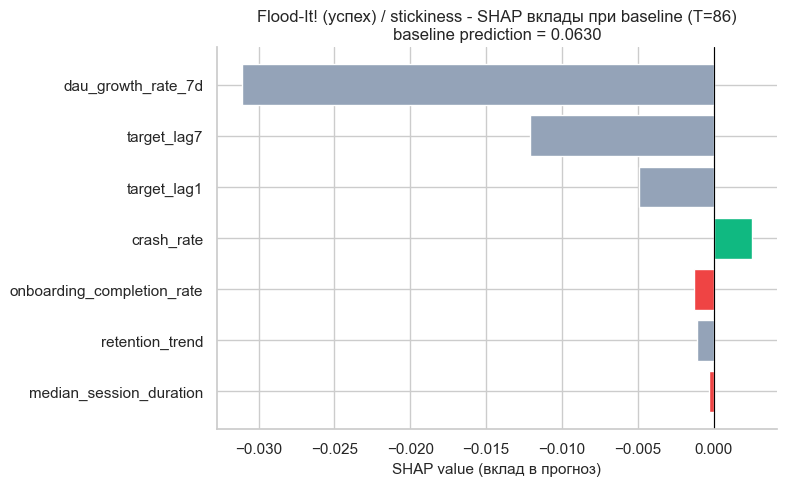

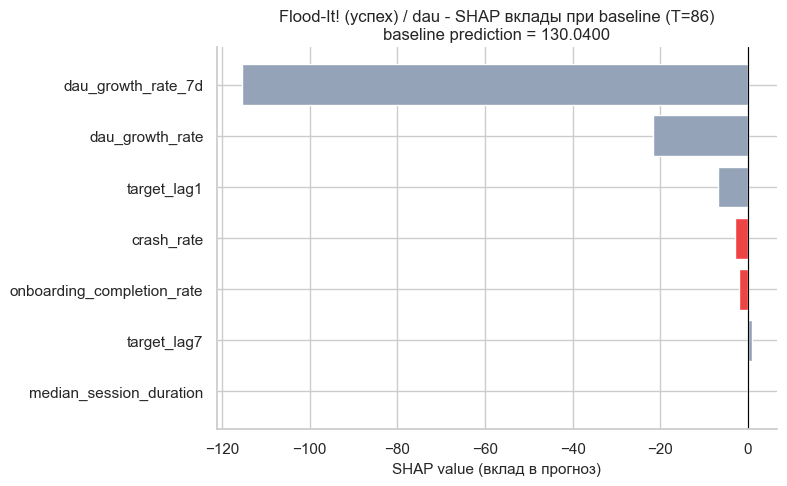

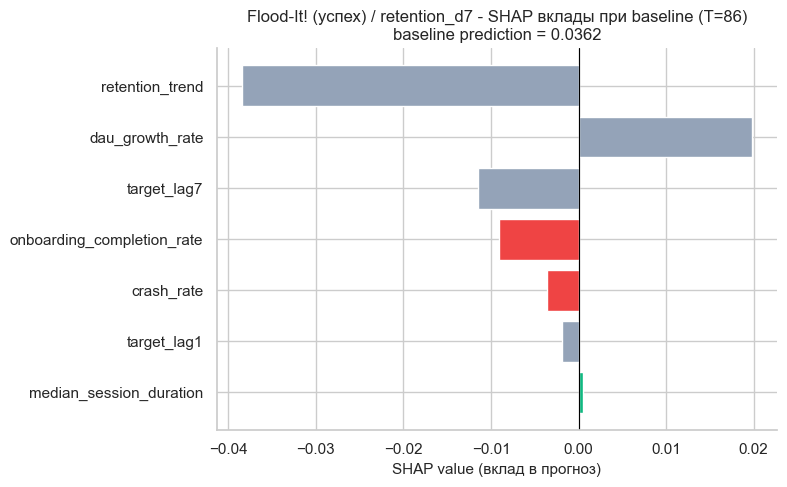

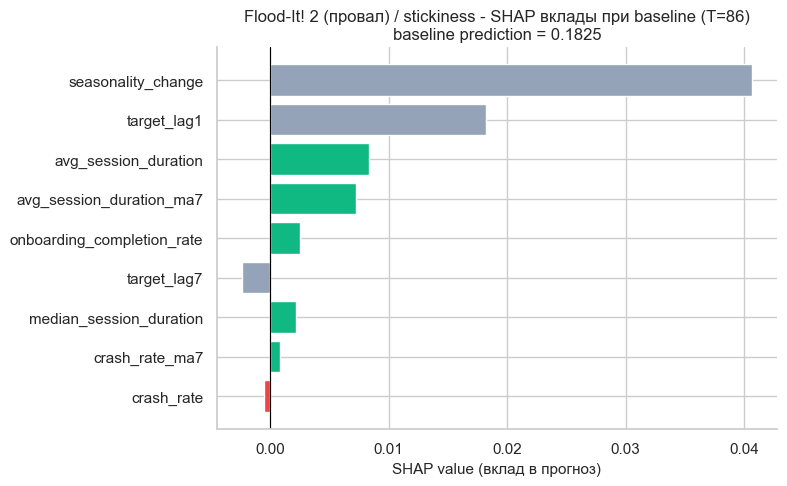

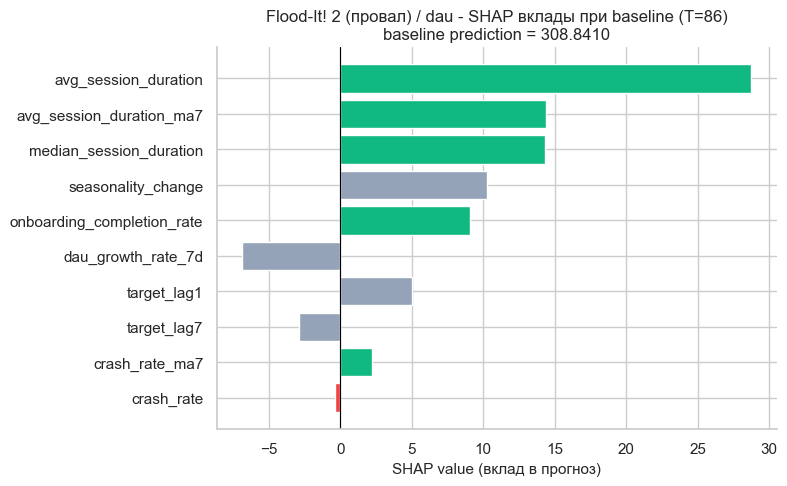

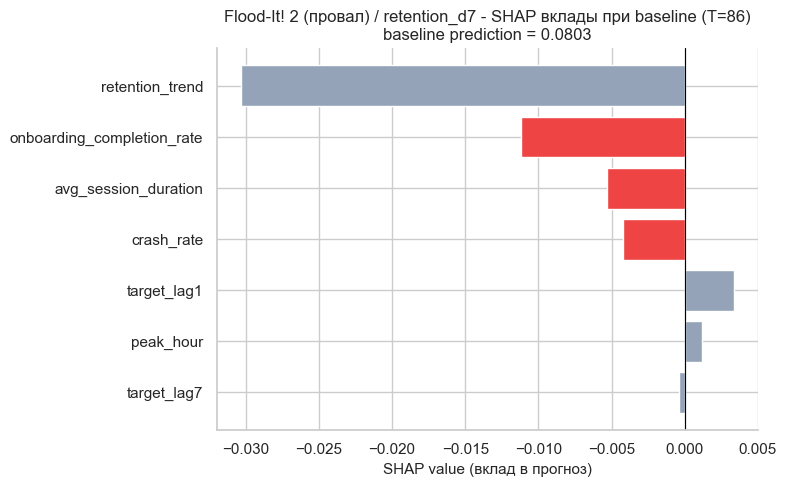

Generated 6 SHAP bar plots.


In [11]:
# 1. SHAP bar plots per pair
for app_id, target in PAIRS:
    app_key = "f1" if app_id == APP_F1 else "f2"
    trained = trained_models[(app_id, target)]
    shap_res = shap_results[(app_id, target)]
    ops_set = set(FINAL_CONFIG[app_key][target].get("operational_features", []))
    is_op = [f in ops_set for f in trained["feature_names"]]
    _plot_shap_bar(
        shap_values=shap_res["shap_values"],
        feature_names=trained["feature_names"],
        is_operational=is_op,
        app_id=app_id, target=target,
        baseline_pred=shap_res["baseline_pred"],
    )
    plt.show()
print(f"Generated 6 SHAP bar plots.")


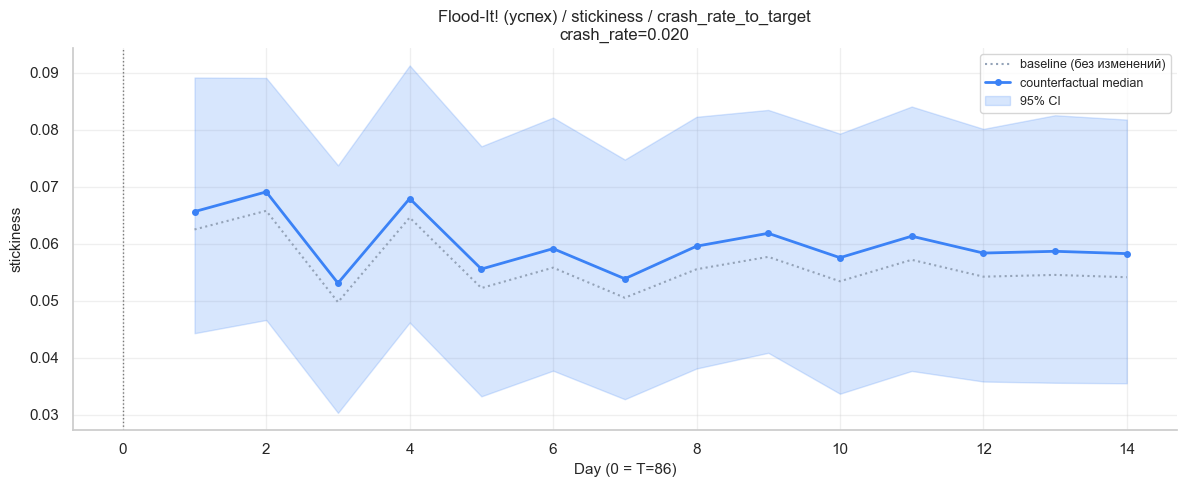

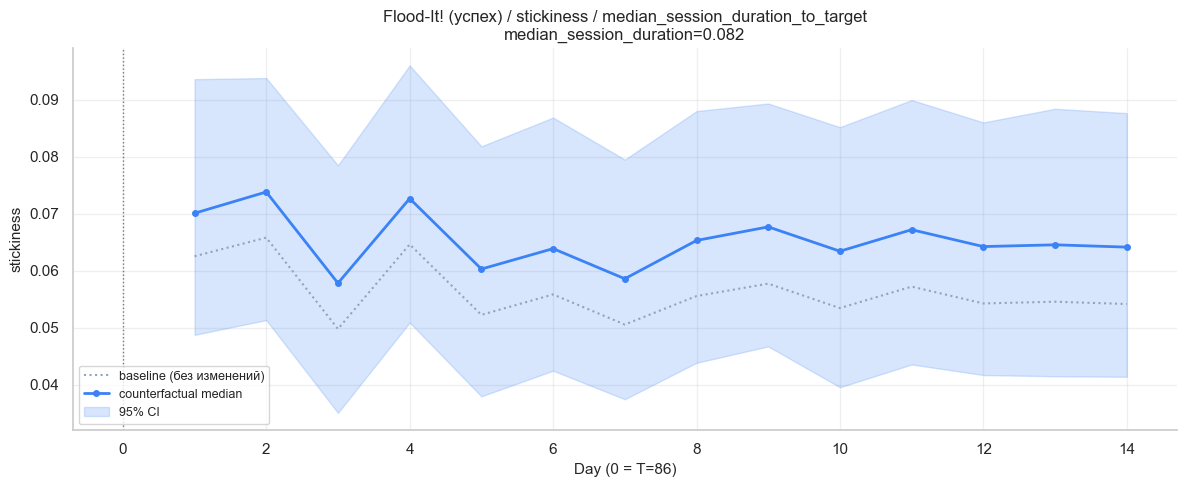

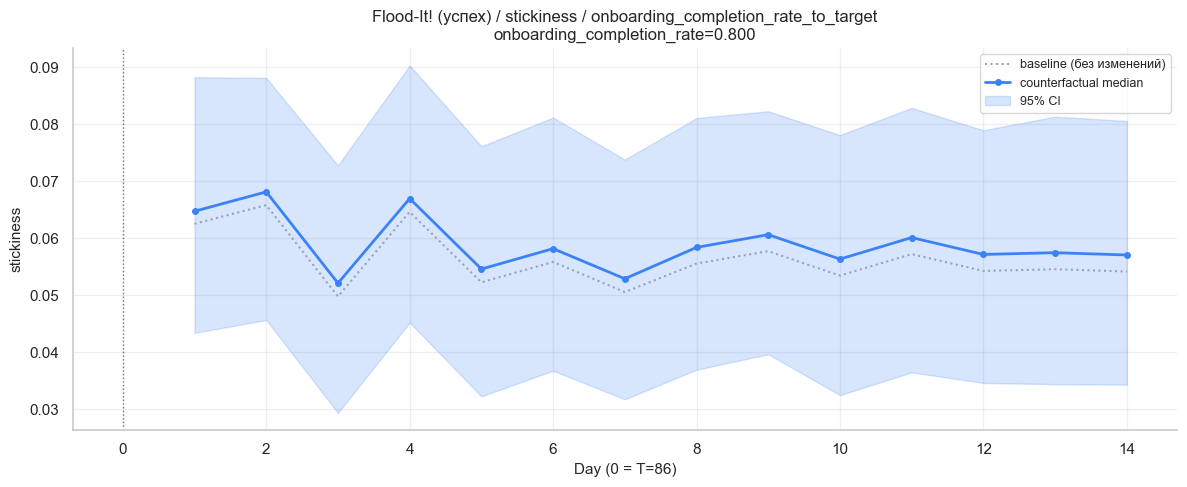

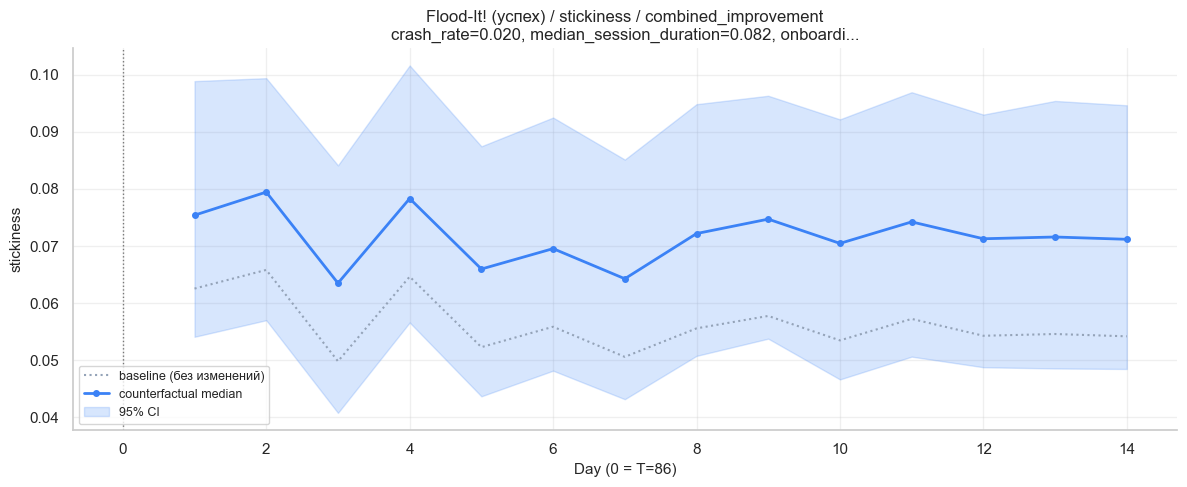

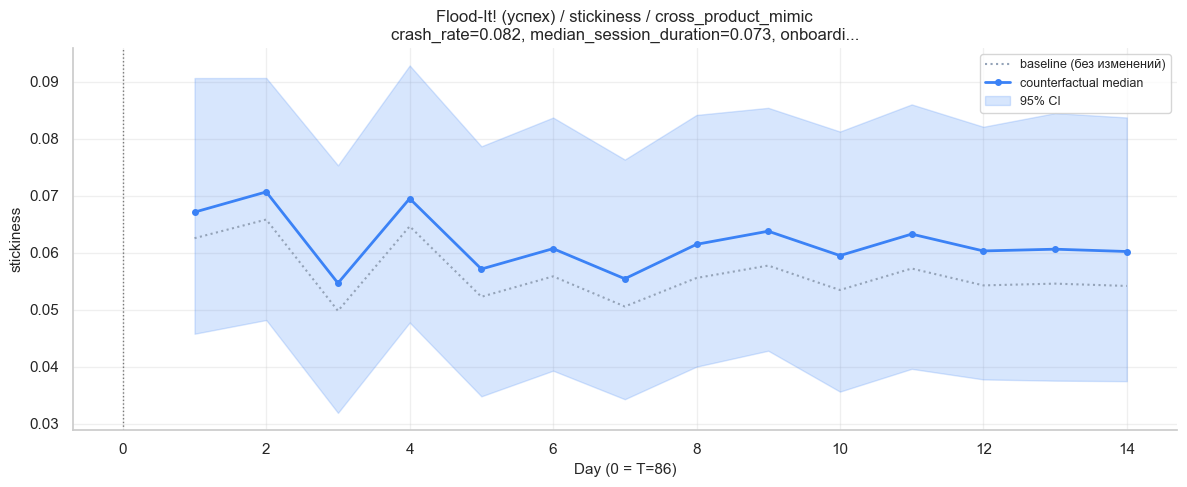

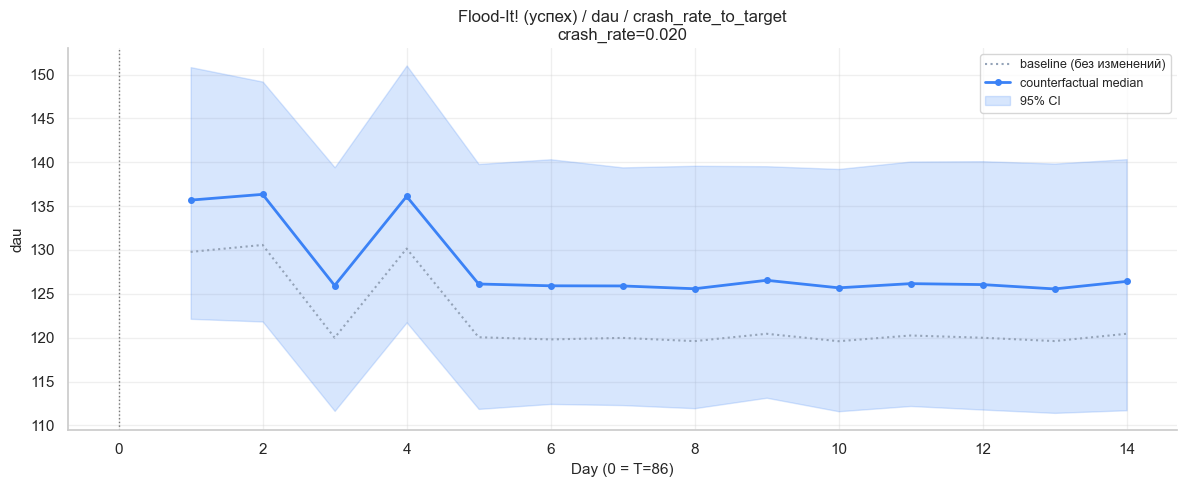

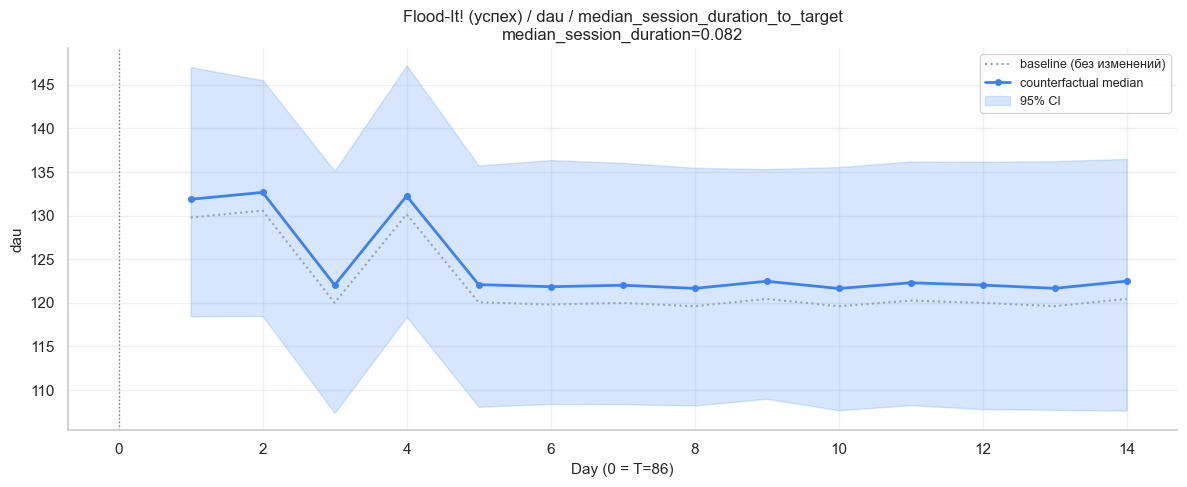

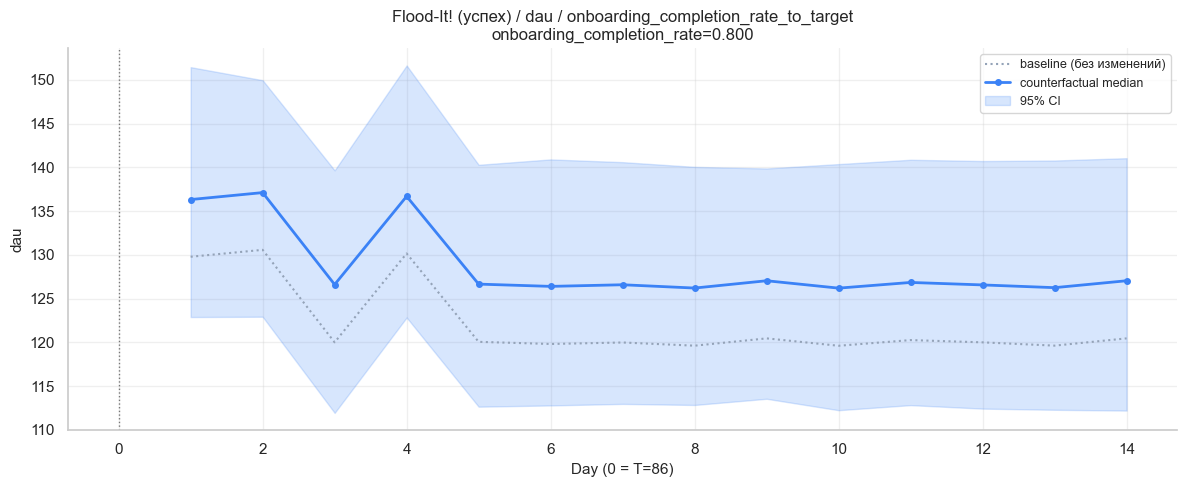

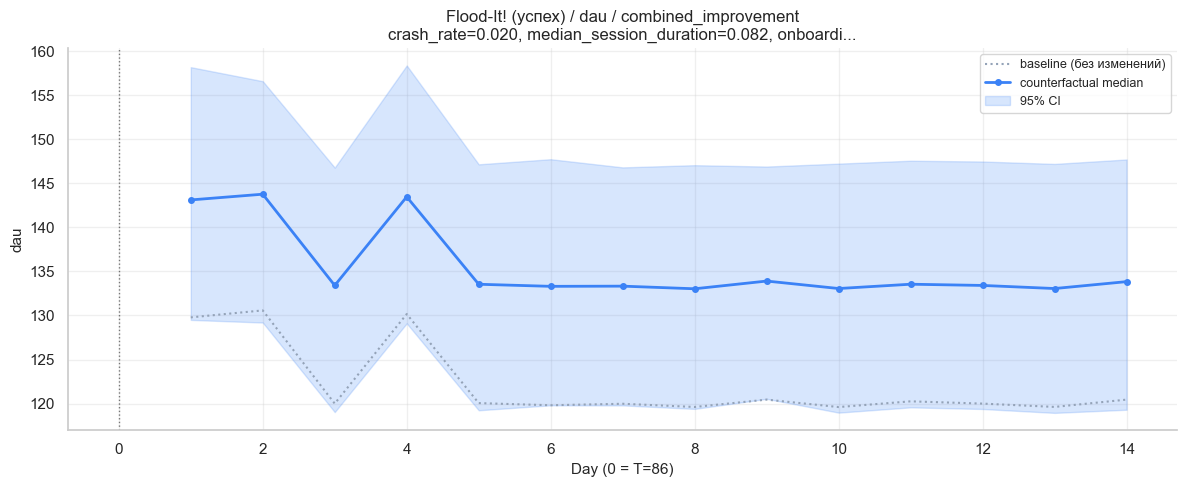

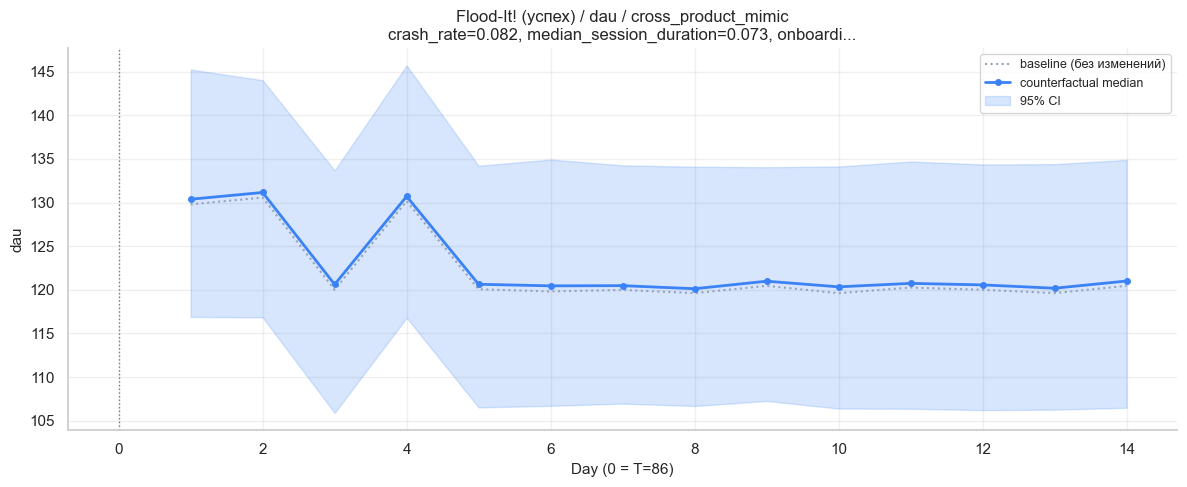

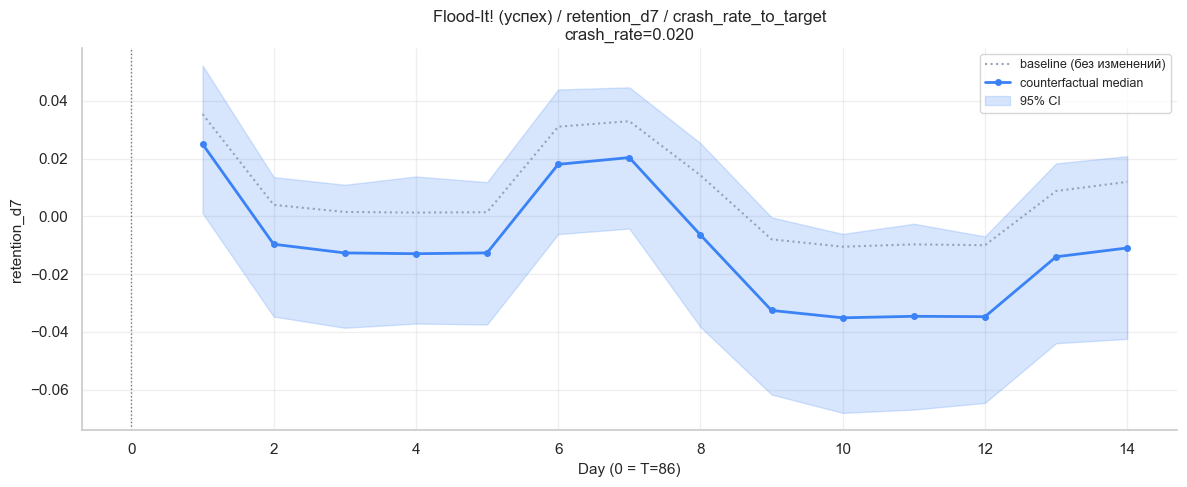

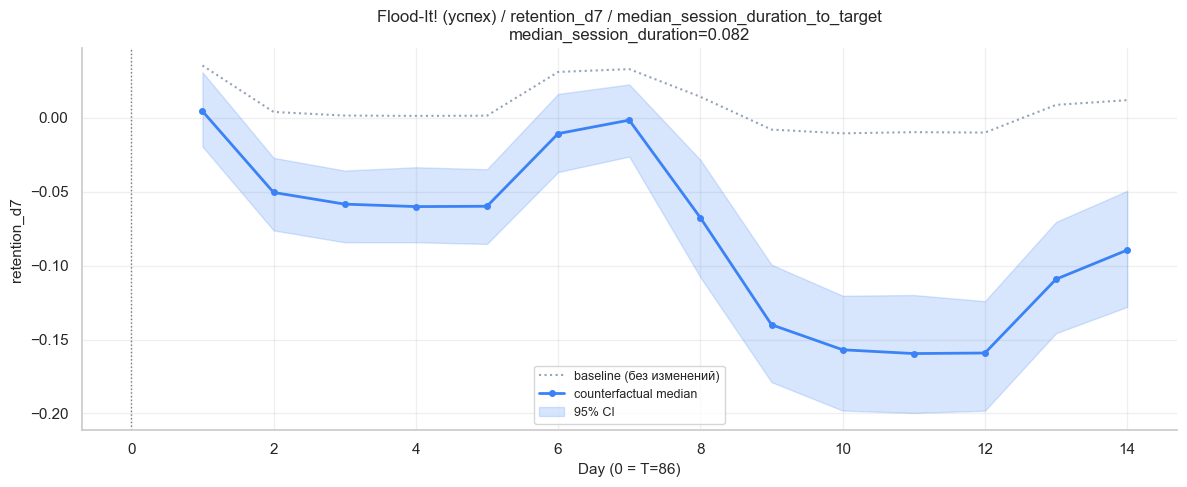

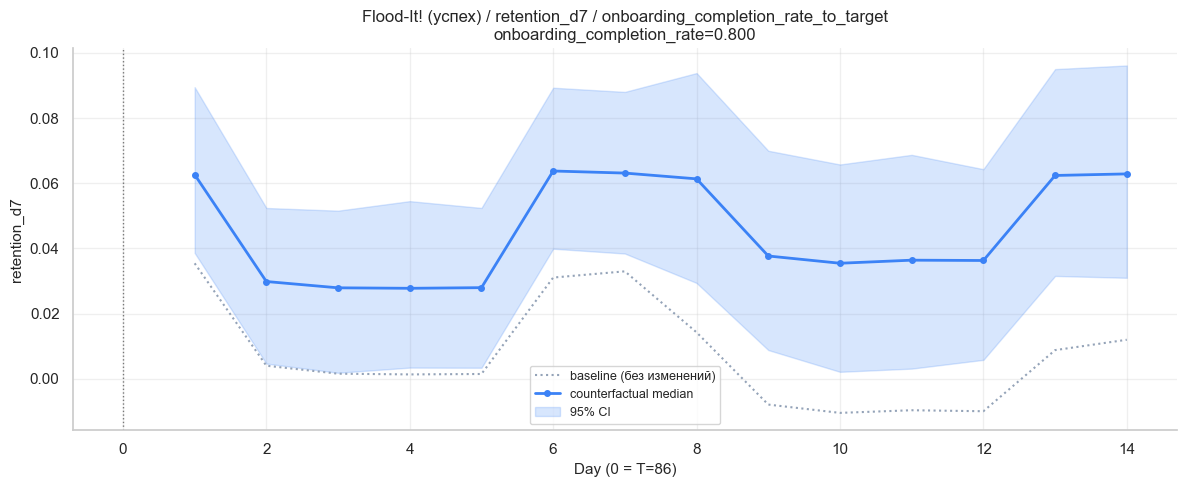

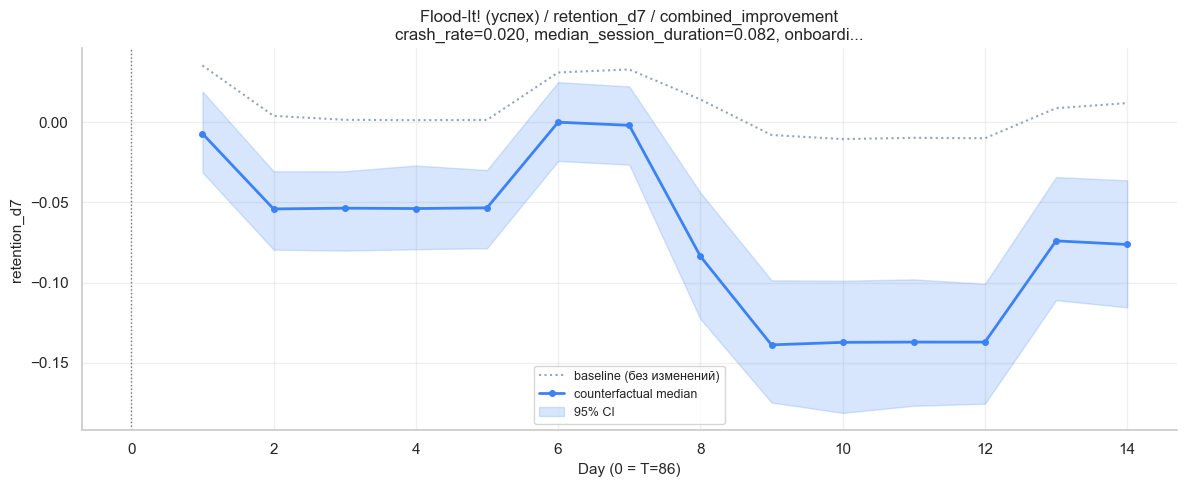

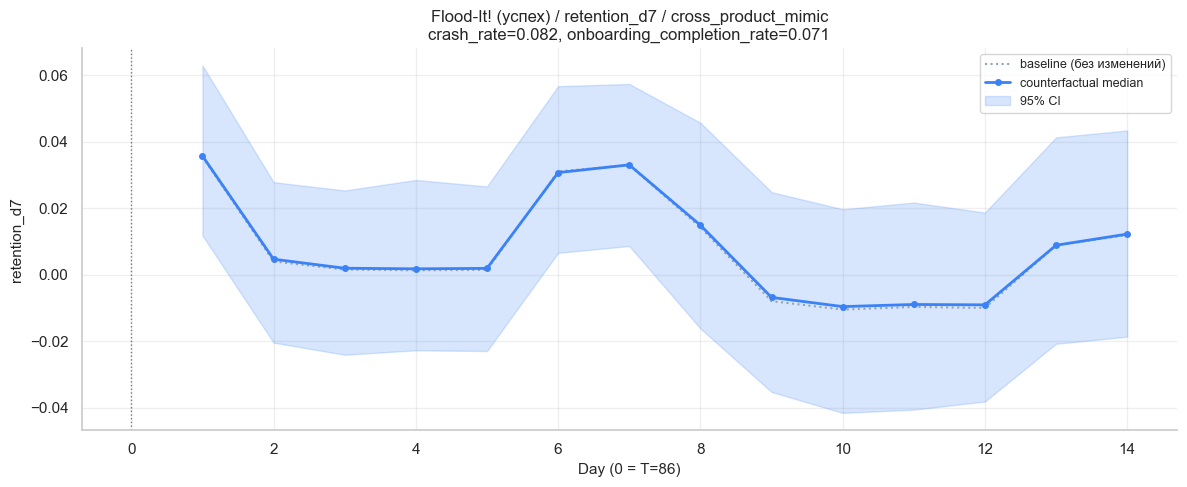

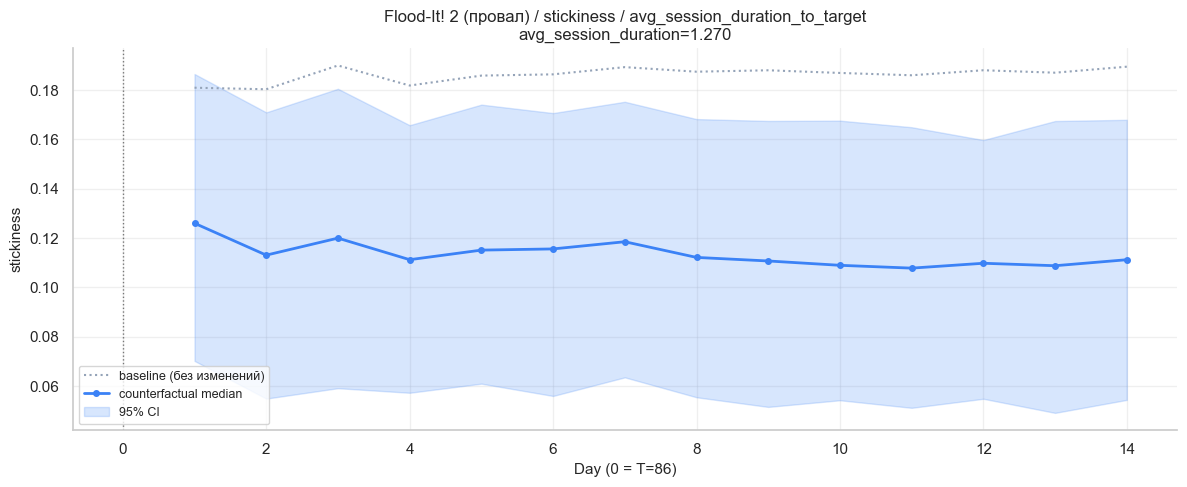

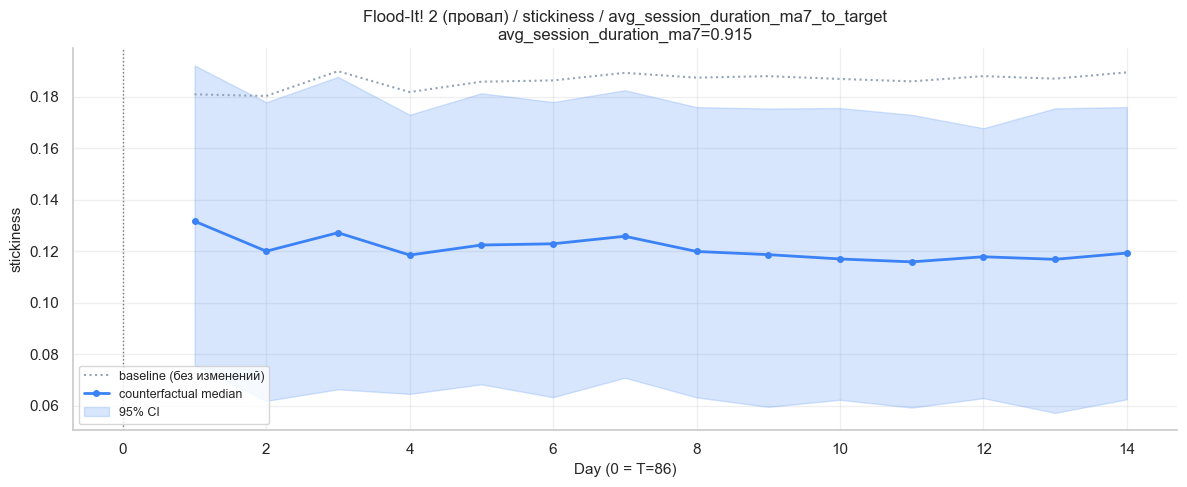

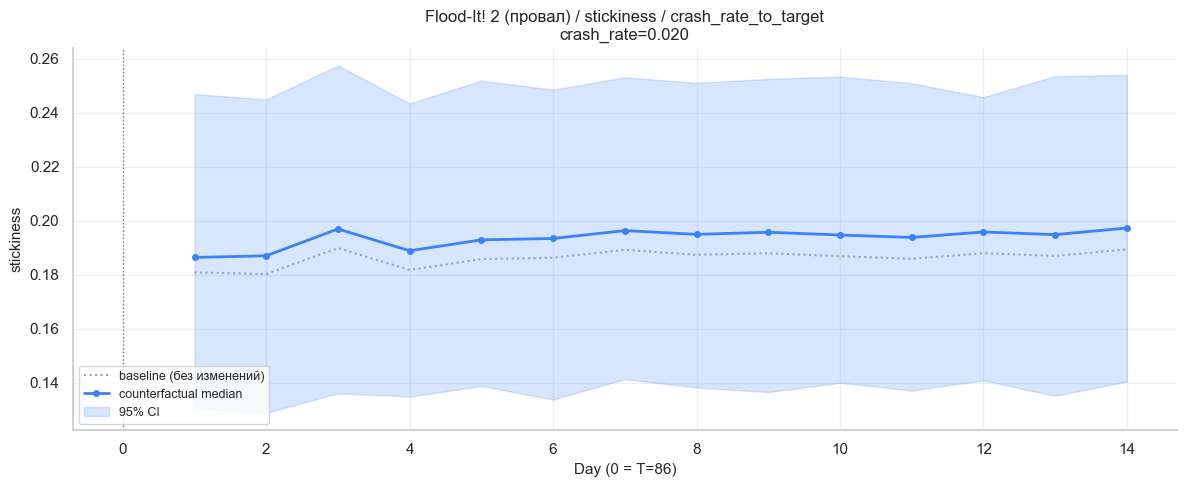

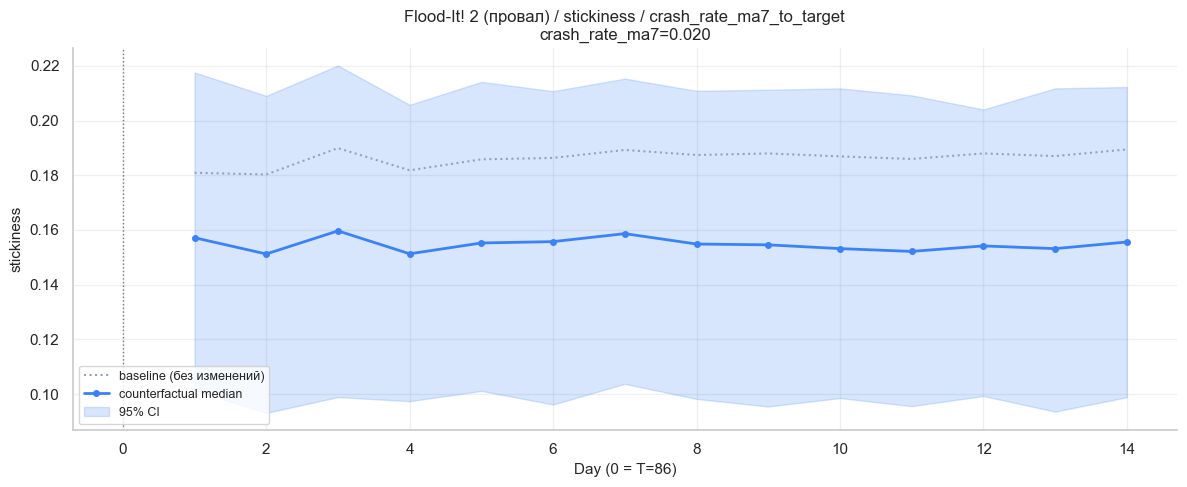

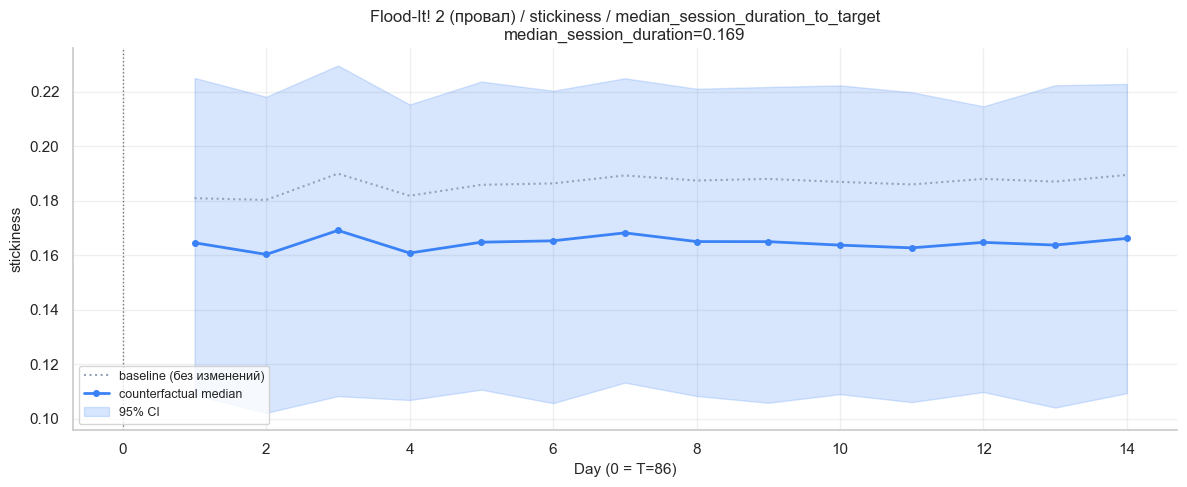

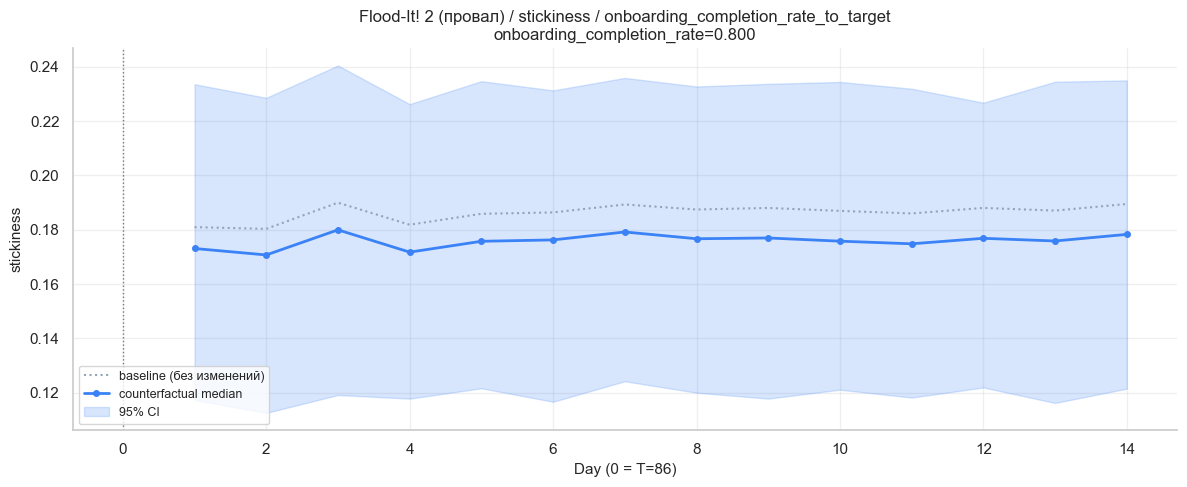

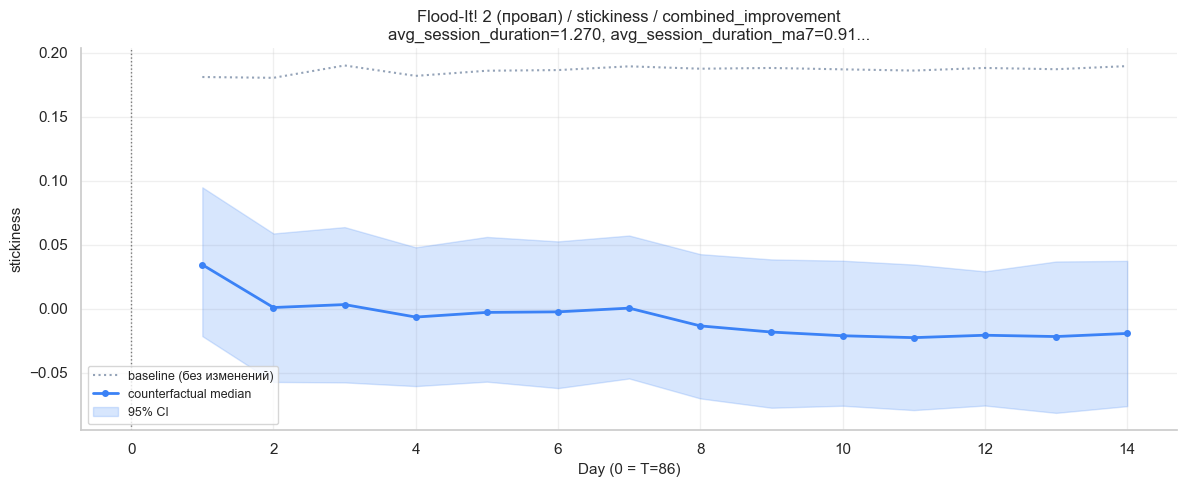

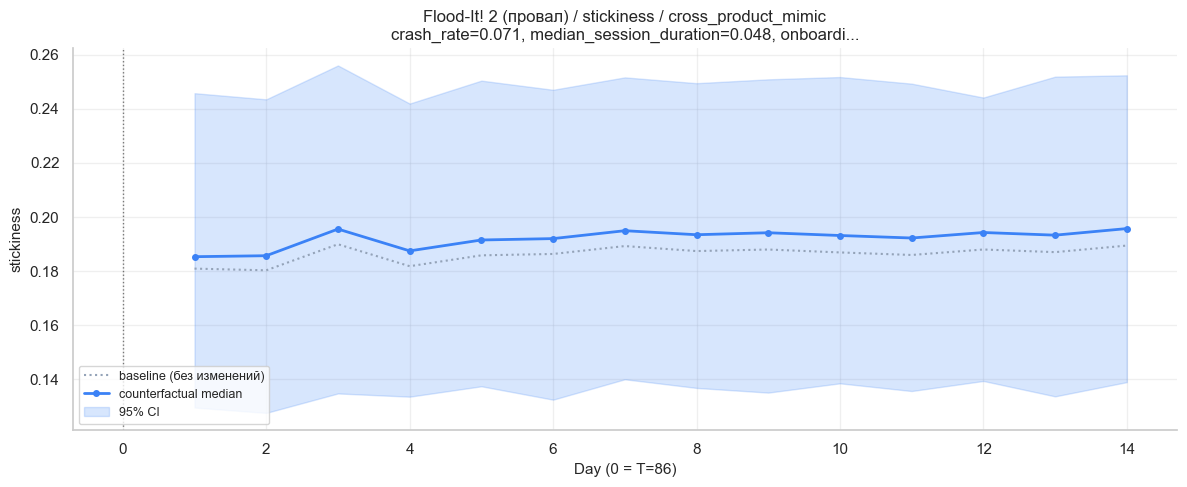

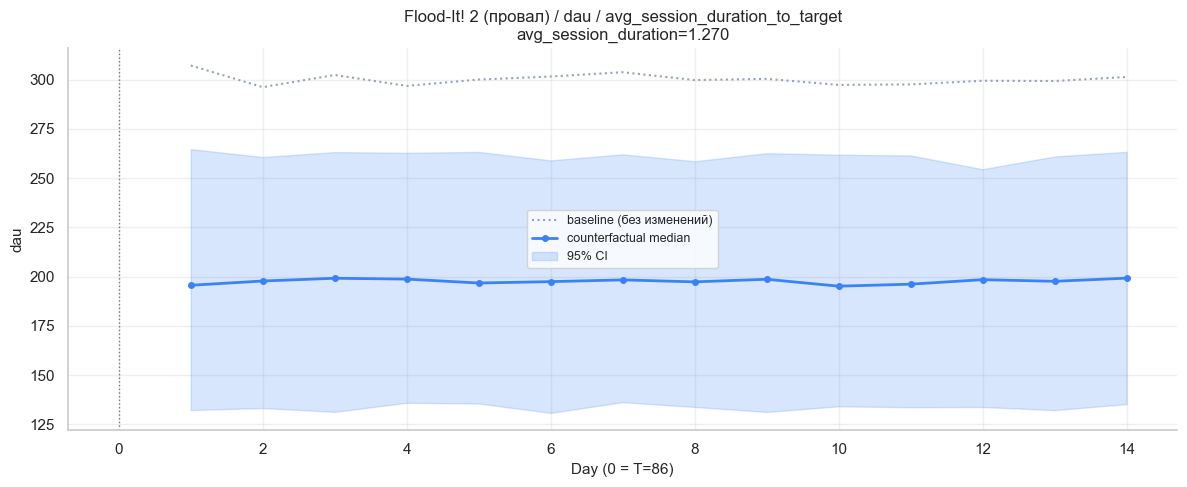

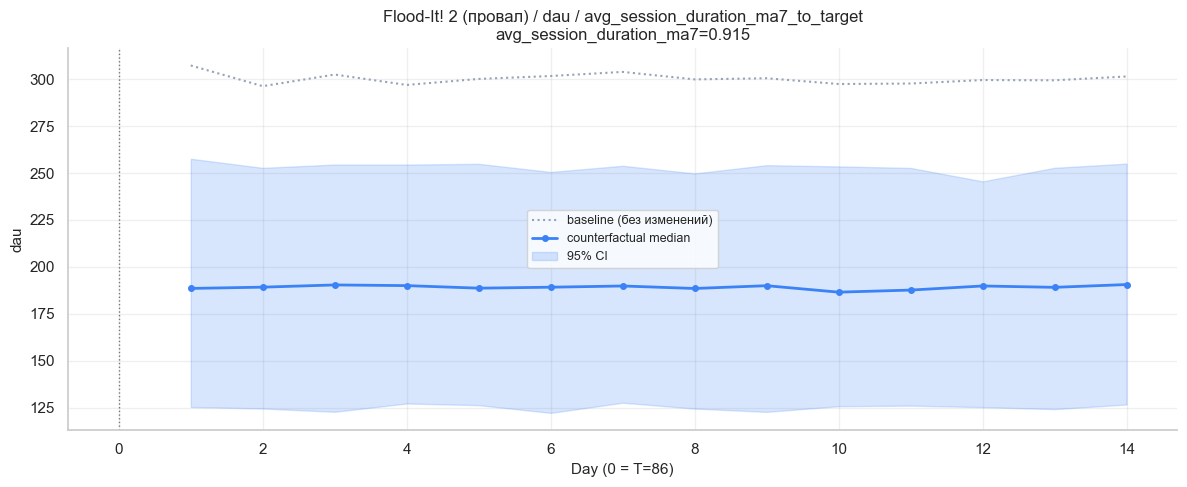

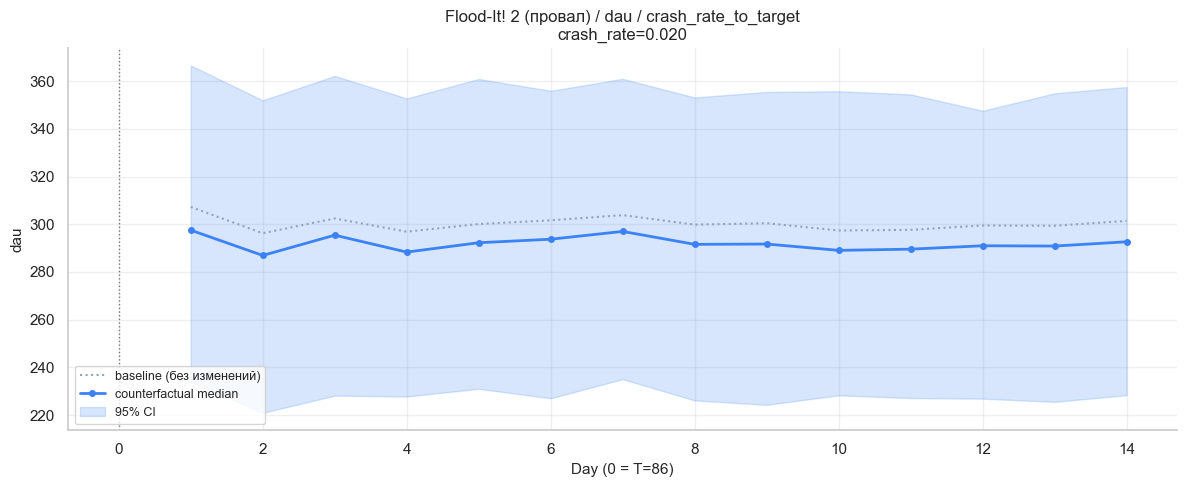

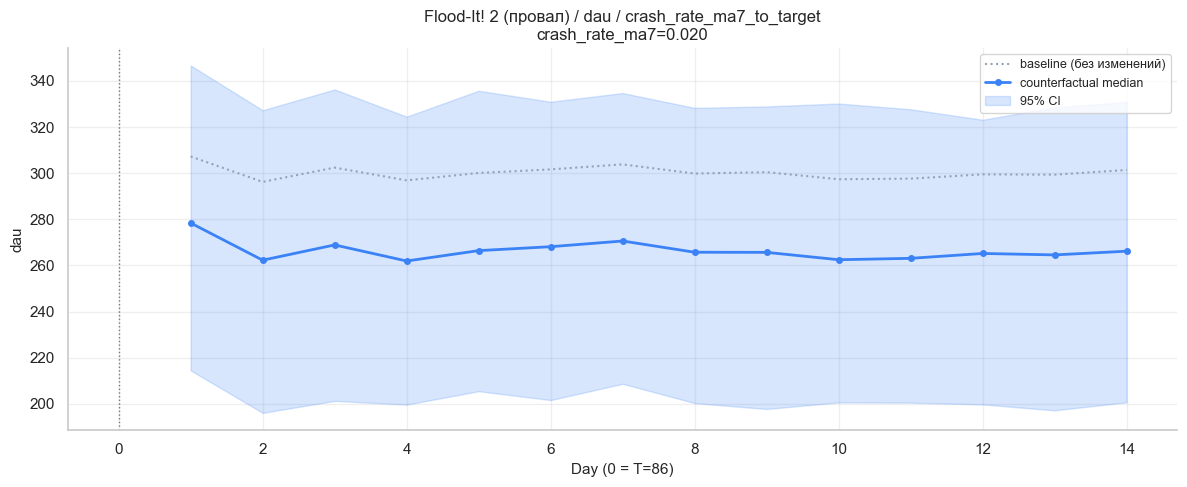

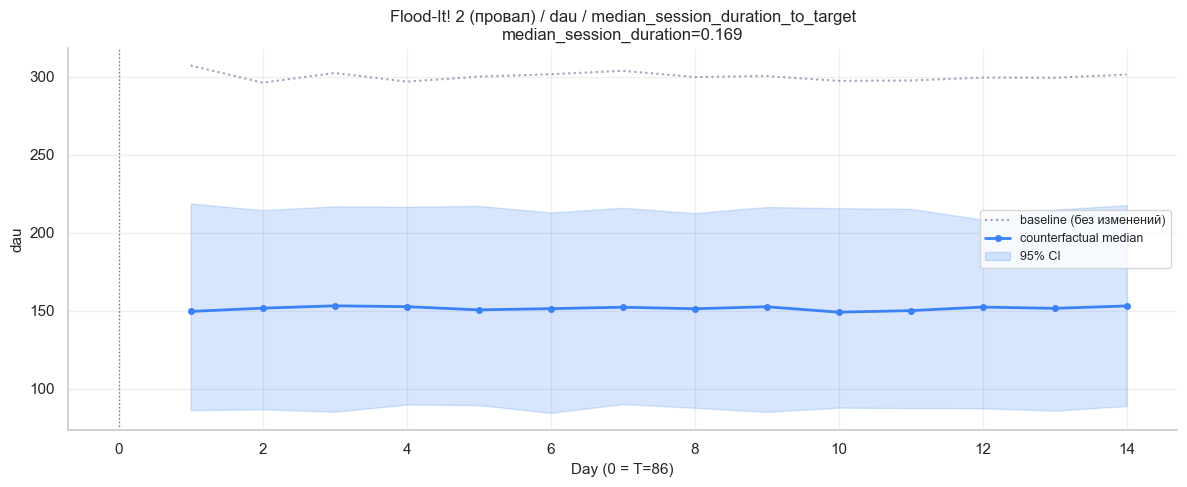

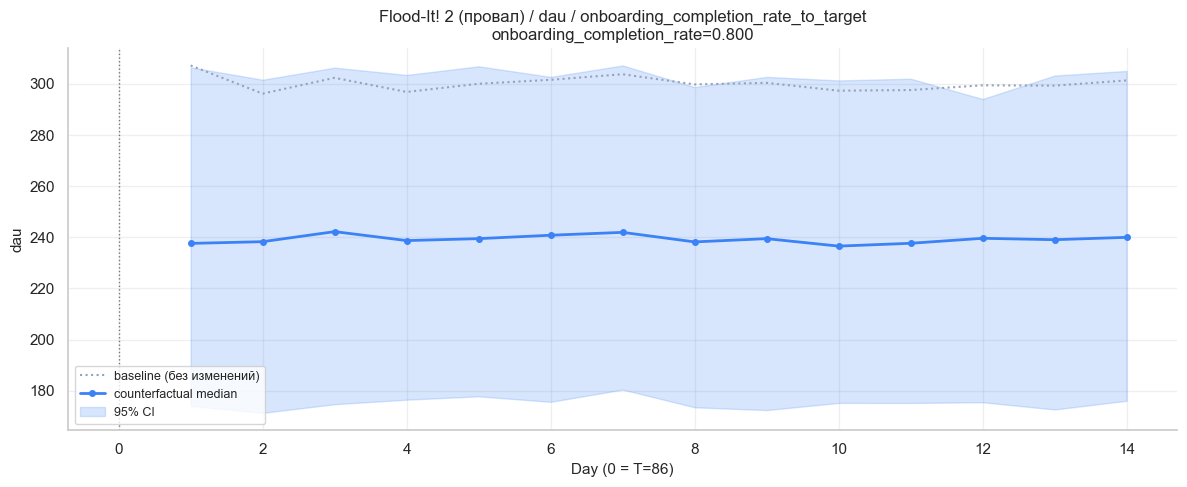

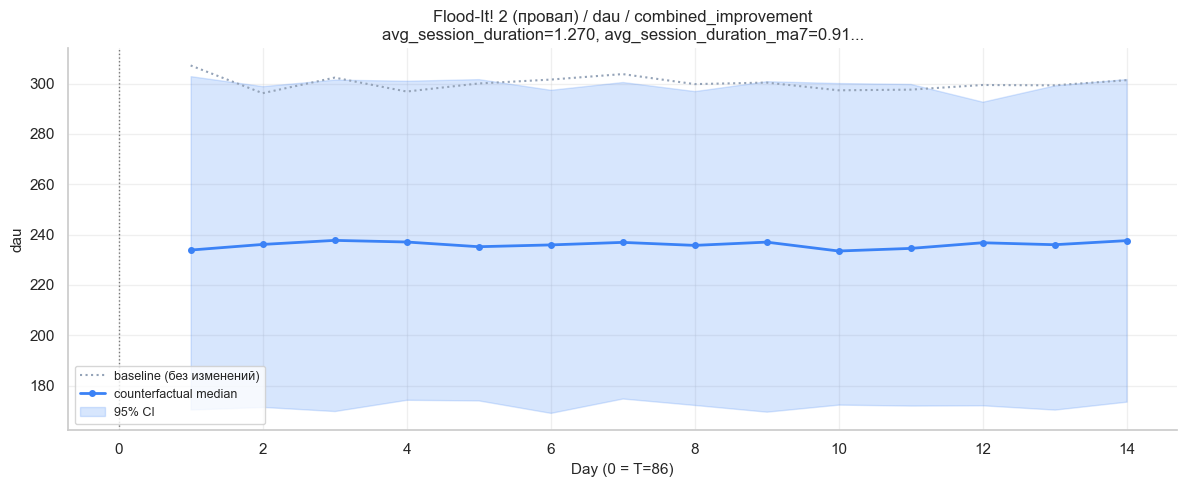

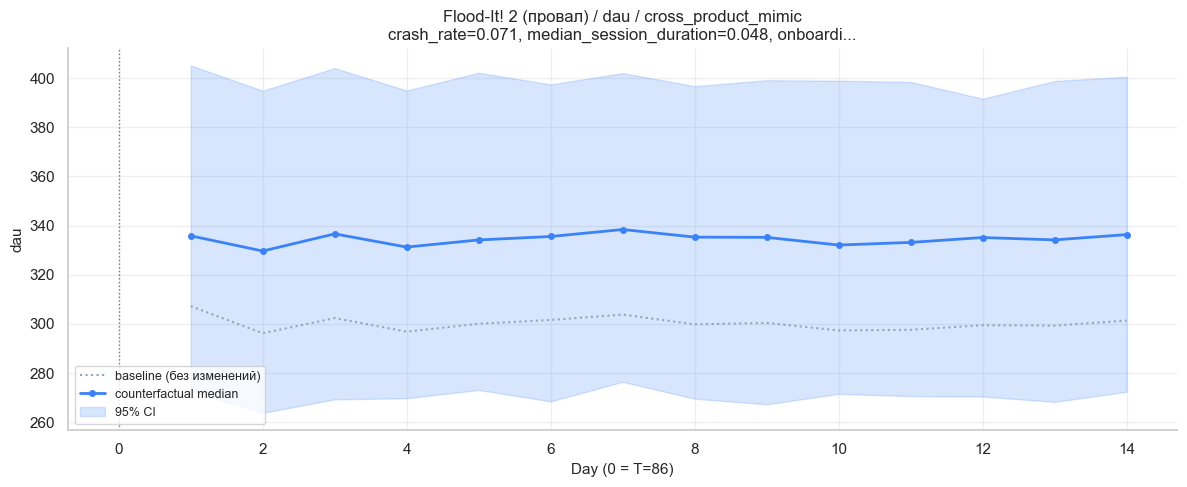

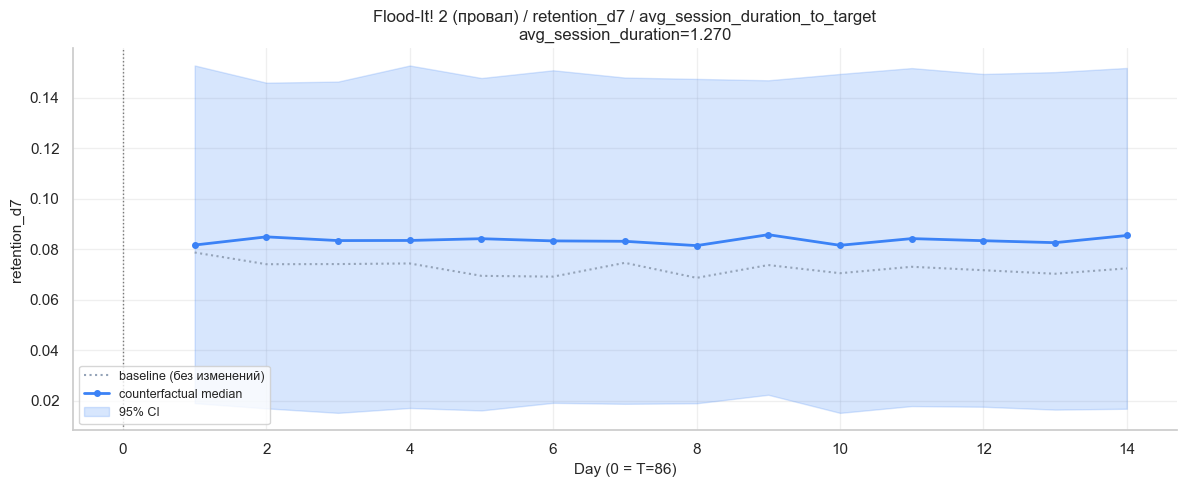

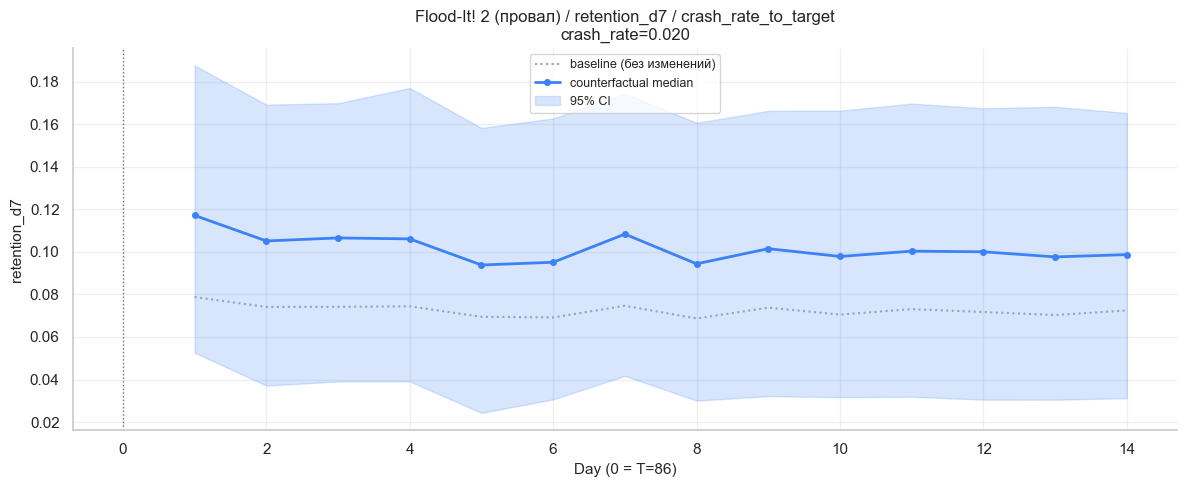

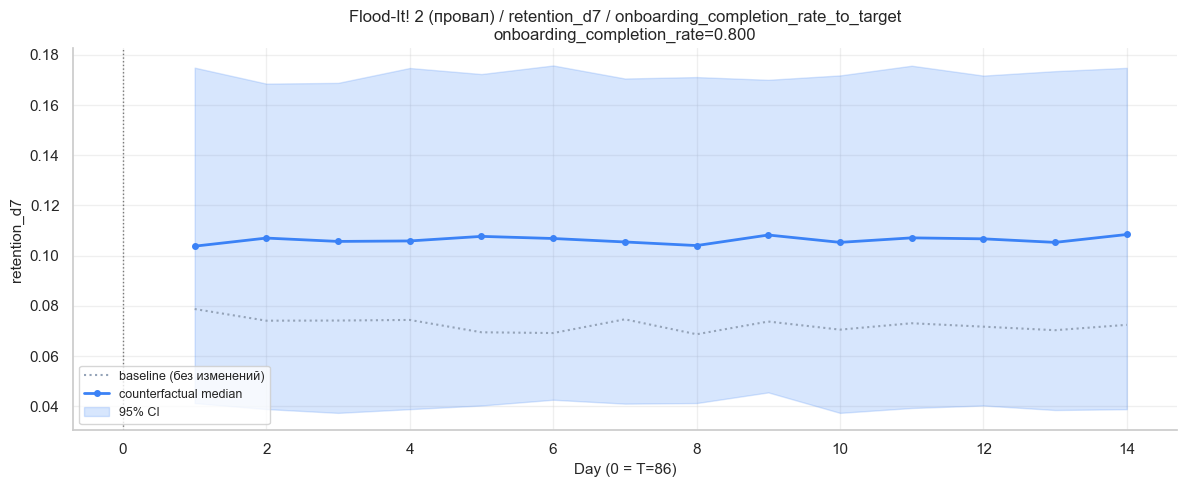

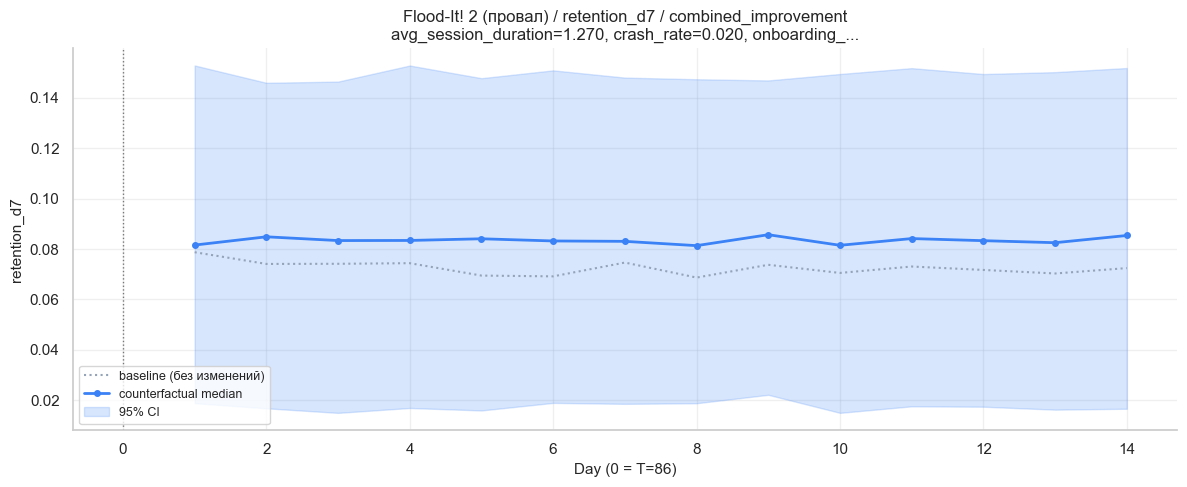

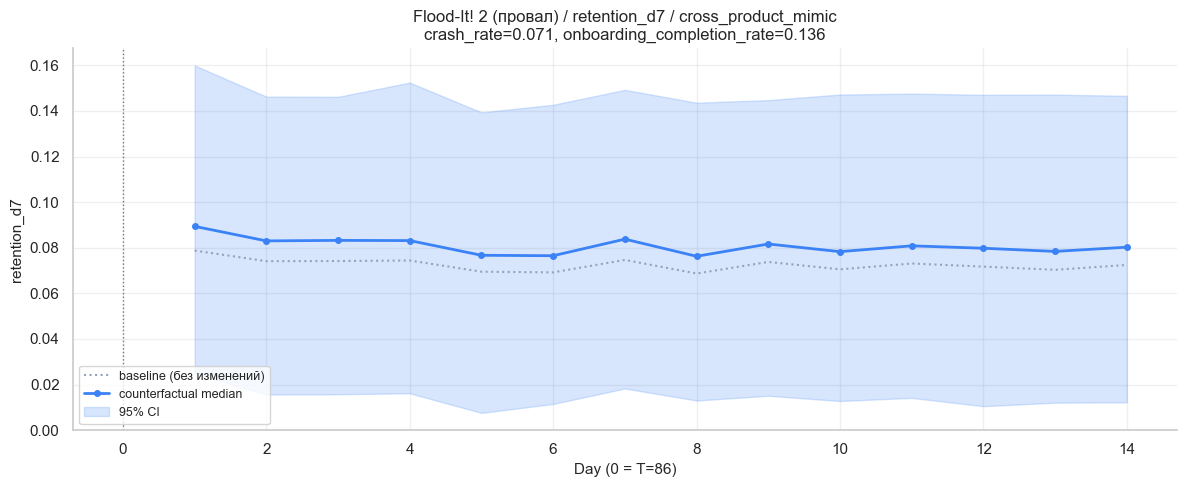

Generated 36 individual scenario trajectory plots.


In [12]:
# 2. Individual scenario trajectories
n_individual = 0
for (app_id, target), pair_results in scenario_results.items():
    baseline_traj = pair_results["baseline"]["median_traj"]
    for name, res in pair_results.items():
        if name == "baseline":
            continue
        changes_text = ", ".join(f"{k}={v:.3f}" for k, v in res["changes"].items())
        if len(changes_text) > 60:
            changes_text = changes_text[:57] + "..."
        _plot_scenario_trajectory(
            median_traj=res["median_traj"],
            ci_lo_traj=res["ci_lo_traj"],
            ci_hi_traj=res["ci_hi_traj"],
            baseline_traj=baseline_traj,
            app_id=app_id, target=target, scenario_name=name,
            changes_text=changes_text,
        )
        plt.show()
        n_individual += 1
print(f"Generated {n_individual} individual scenario trajectory plots.")


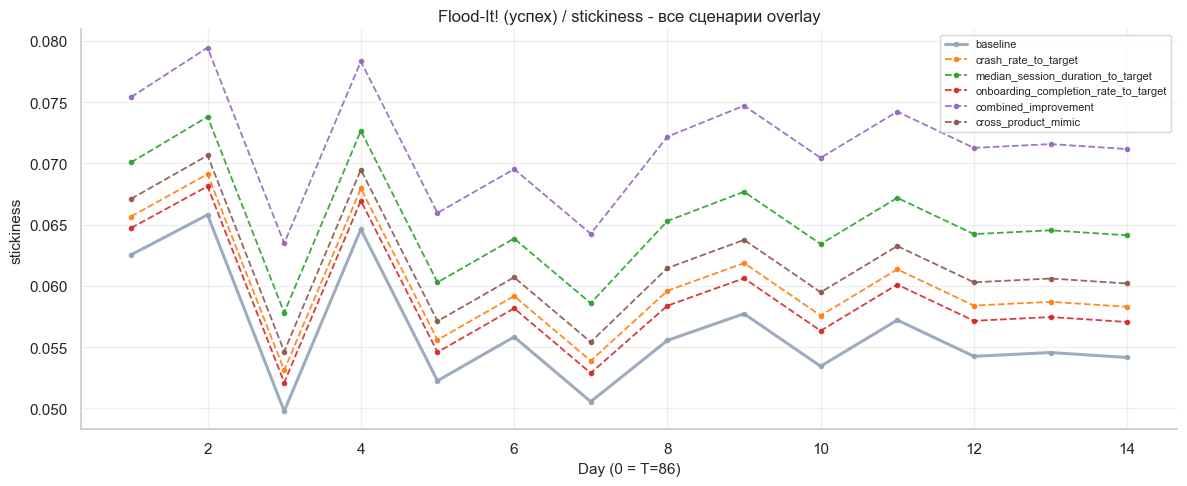

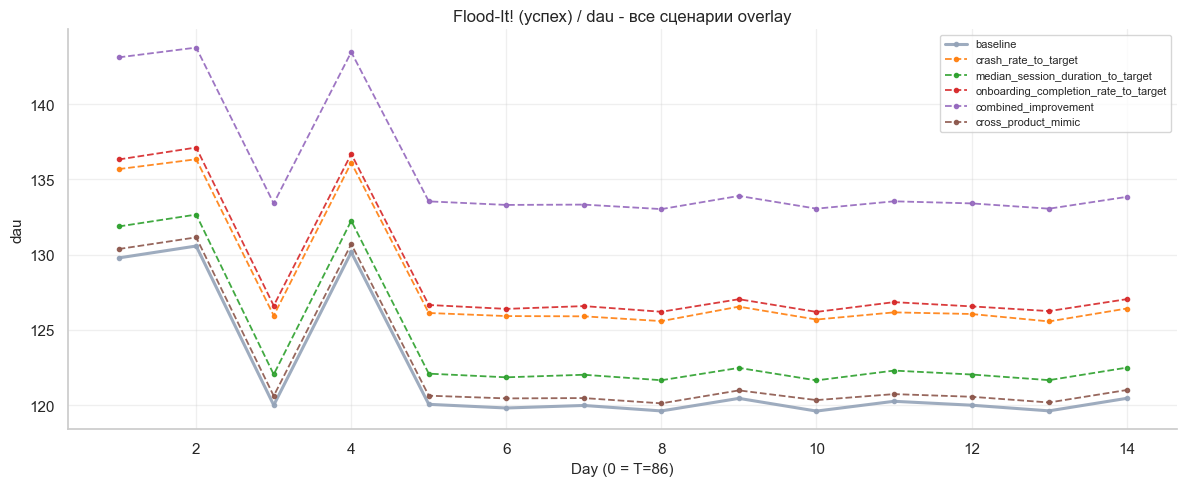

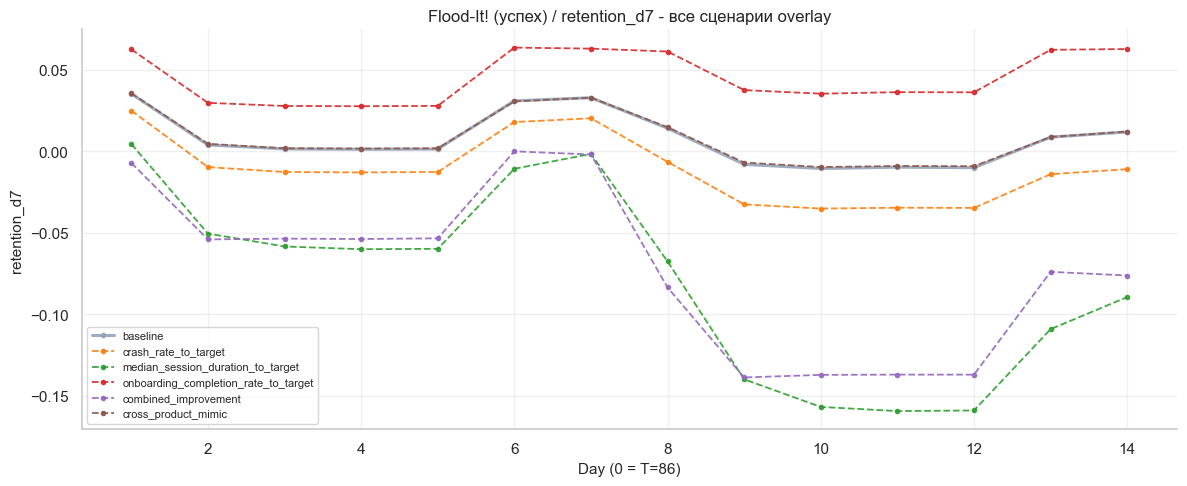

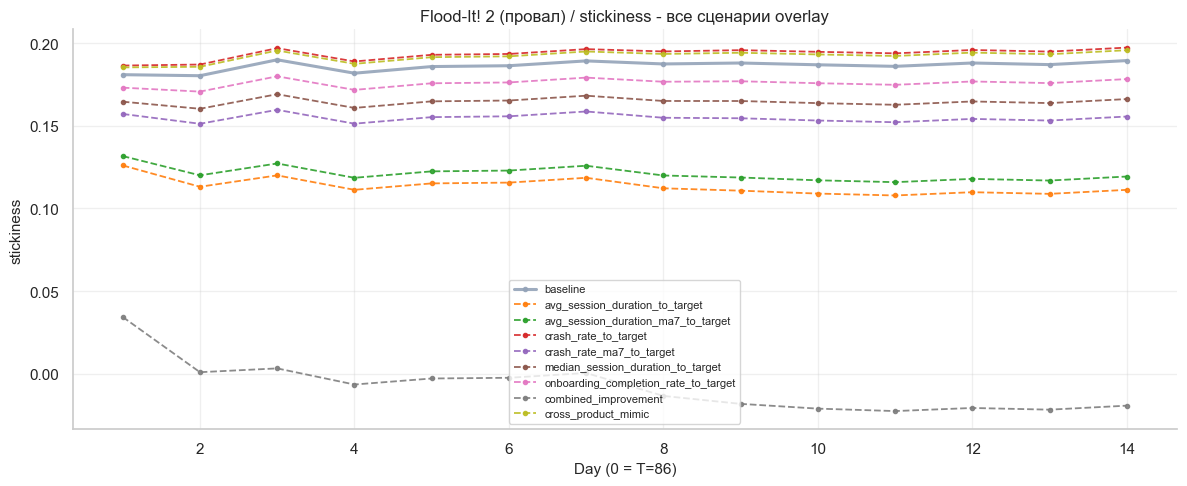

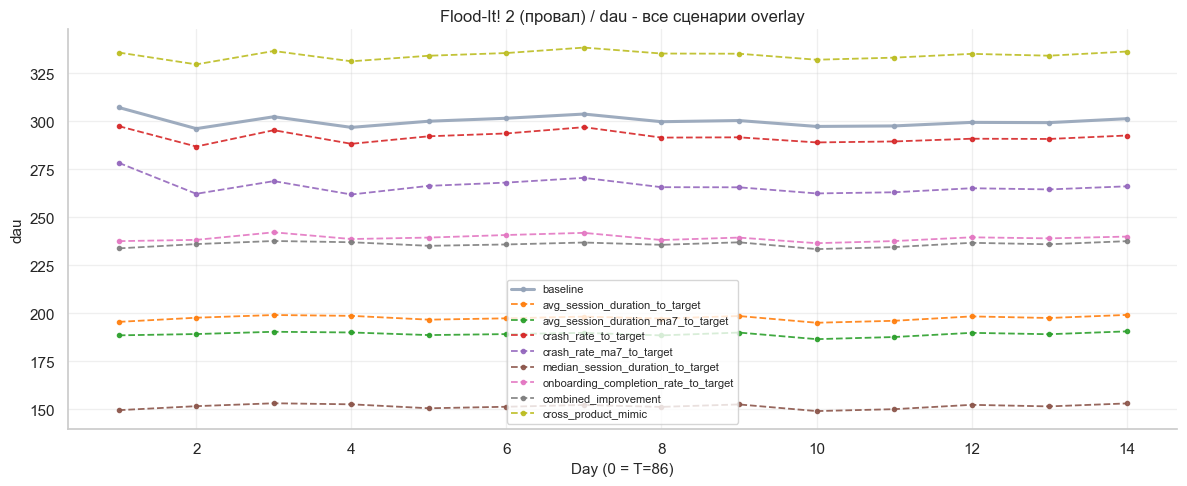

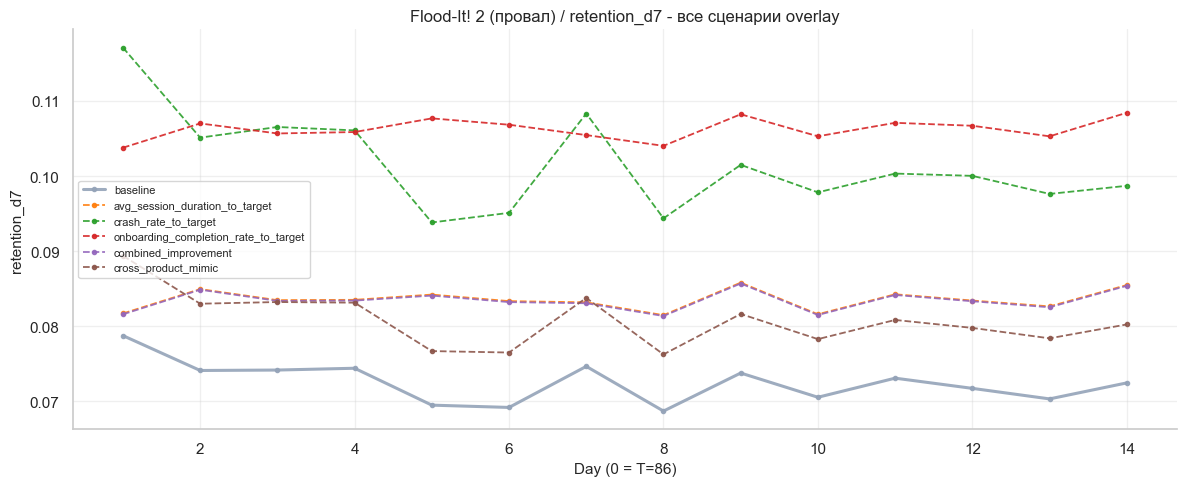

Generated 6 comparison panels.


In [13]:
# 3. Comparison panels per pair
for (app_id, target), pair_results in scenario_results.items():
    _plot_pair_comparison(pair_results, app_id, target)
    plt.show()
print(f"Generated 6 comparison panels.")


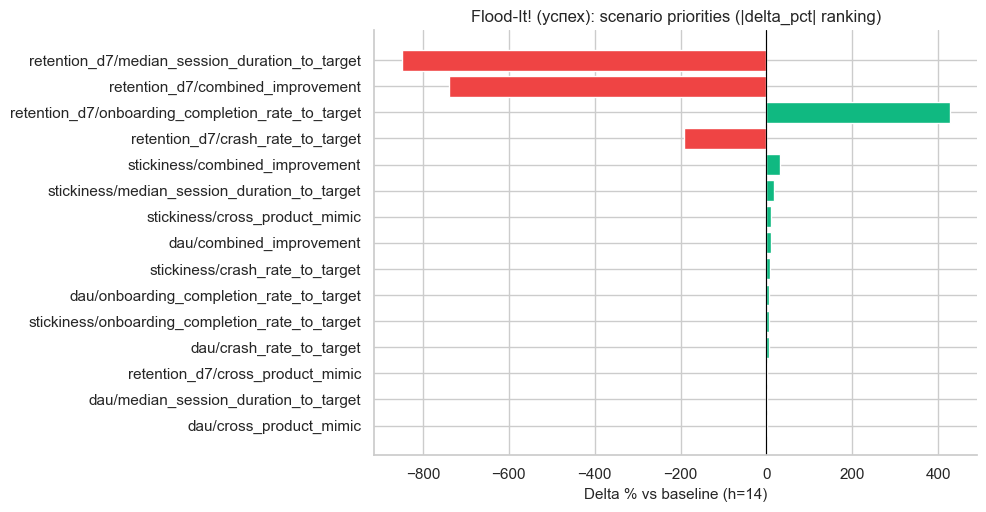

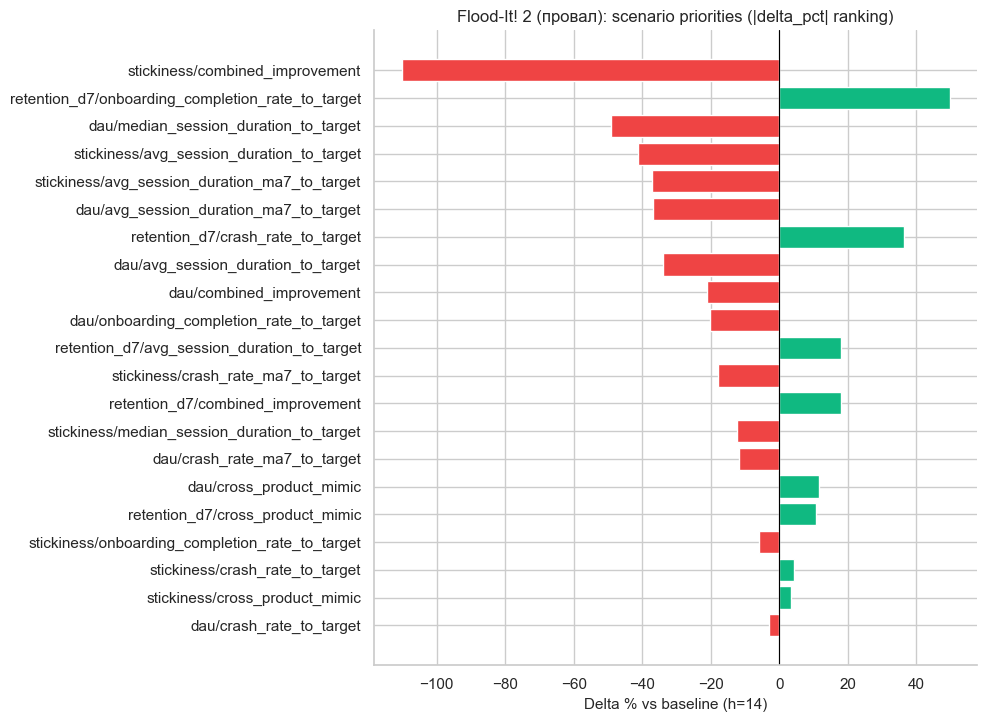

Generated 2 priority charts.


In [14]:
# 4. Priority bar charts per product
def _plot_priority_chart(app_label_str: str, app_key: str):
    """Bar chart: top scenarios by |delta_pct| for given product."""
    sub = scenario_df[(scenario_df["app"] == app_key) &
                       (scenario_df["scenario_name"] != "baseline")]
    if len(sub) == 0:
        return
    sub_sorted = sub.reindex(sub["delta_pct_vs_baseline"].abs().sort_values(ascending=True).index)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(sub_sorted))))
    labels = [f"{r['target']}/{r['scenario_name']}" for _, r in sub_sorted.iterrows()]
    deltas = sub_sorted["delta_pct_vs_baseline"].values
    colors = ["#10b981" if d > 0 else "#ef4444" for d in deltas]
    ax.barh(labels, deltas, color=colors)
    ax.axvline(0, color="#000", linewidth=0.8)
    ax.set_title(f"{app_label_str}: scenario priorities (|delta_pct| ranking)")
    ax.set_xlabel("Delta % vs baseline (h=14)")
    plt.tight_layout()
    fname = f"recommendations_{app_key}"
    save_figure(fname, NOTEBOOK_SLUG)


for app_id, app_key in [(APP_F1, "f1"), (APP_F2, "f2")]:
    _plot_priority_chart(app_label(app_id), app_key)
    plt.show()
print(f"Generated 2 priority charts.")


## 7. Recommendations table

Per product (f1, f2): топ-2 приоритета улучшения с прогнозируемым ROI.
Связка `SHAP pain score` × `scenario delta_pct` → ранжирование действий.

In [15]:
recommendations_rows = []
avoid_actions_rows = []

for app_id, app_key in [(APP_F1, "f1"), (APP_F2, "f2")]:
    for target in TARGETS:
        # SHAP pain scores per ops feature for this pair
        shap_pair = shap_df[(shap_df["app"] == app_key) & (shap_df["target"] == target)
                              & (shap_df["is_operational"])]
        ops_pain = {r["feature"]: float(r["shap_value"]) for _, r in shap_pair.iterrows()}

        # Single-feature scenarios for this pair
        single = scenario_df[(scenario_df["app"] == app_key) & (scenario_df["target"] == target)
                              & (scenario_df["scenario_type"] == "single")]
        if len(single) == 0:
            continue

        ranked = []
        for _, r in single.iterrows():
            changes = json.loads(r["scenario_changes_json"])
            feature = list(changes.keys())[0]
            target_val = changes[feature]
            pain = ops_pain.get(feature, 0.0)
            delta = float(r["delta_pct_vs_baseline"])
            p_succ = float(r["p_exceed_baseline"])
            ci_lo = float(r["ci95_lo_h14"])
            ci_hi = float(r["ci95_hi_h14"])
            base = float(r["baseline_prediction"])
            # Extrapolation flag: extreme delta or degenerate p_success
            is_extrap = (abs(delta) > 100.0) or (p_succ in (0.0, 1.0))
            ranked.append({
                "feature": feature, "target_val": target_val,
                "pain": pain, "delta_pct": delta, "p_success": p_succ,
                "ci_lo": ci_lo, "ci_hi": ci_hi, "baseline_pred": base,
                "is_extrap": is_extrap,
            })

        # SIGNED ranking: positive delta first, secondary by |pain|
        # Anti-recommendations (negative delta) -> avoid_actions list
        positive = [x for x in ranked if x["delta_pct"] > 0]
        negative = [x for x in ranked if x["delta_pct"] <= 0]
        positive.sort(key=lambda x: (x["delta_pct"], -x["pain"]), reverse=True)
        negative.sort(key=lambda x: x["delta_pct"])  # most negative first -> biggest "avoid"

        # Top-2 positive priorities (with extrapolation flag)
        for rank, item in enumerate(positive[:2], 1):
            recommendations_rows.append({
                "app": app_key,
                "target": target,
                "priority_rank": rank,
                "action": f"{item['feature']} -> {item['target_val']:.3f}",
                "target_value": round(item["target_val"], 4),
                "shap_pain_score": round(item["pain"], 4),
                "expected_delta_pct": round(item["delta_pct"], 2),
                "ci95_lo_pct": round((item["ci_lo"] - item["baseline_pred"]) /
                                       abs(item["baseline_pred"]) * 100, 2)
                              if abs(item["baseline_pred"]) > 1e-12 else 0.0,
                "ci95_hi_pct": round((item["ci_hi"] - item["baseline_pred"]) /
                                       abs(item["baseline_pred"]) * 100, 2)
                              if abs(item["baseline_pred"]) > 1e-12 else 0.0,
                "p_success": round(item["p_success"], 3),
                "extrapolation_warning": item["is_extrap"],
            })

        # Top-2 anti-actions (model says "doing this hurts")
        for rank, item in enumerate(negative[:2], 1):
            avoid_actions_rows.append({
                "app": app_key,
                "target": target,
                "avoid_rank": rank,
                "action": f"{item['feature']} -> {item['target_val']:.3f}",
                "target_value": round(item["target_val"], 4),
                "shap_pain_score": round(item["pain"], 4),
                "expected_delta_pct": round(item["delta_pct"], 2),
                "p_success": round(item["p_success"], 3),
                "extrapolation_warning": item["is_extrap"],
            })

recommendations_df = pd.DataFrame(recommendations_rows)
csv_path = ROOT / "results" / "scenario_recommendations.csv"
recommendations_df.to_csv(csv_path, index=False, encoding="utf-8")
print(f"Saved: {csv_path}")
print(f"Total recommendations (positive ROI only): {len(recommendations_df)}")
print()
print(recommendations_df.to_string(index=False))

# Save anti-actions separately for transparency
avoid_df = pd.DataFrame(avoid_actions_rows)
avoid_path = ROOT / "results" / "scenario_avoid_actions.csv"
avoid_df.to_csv(avoid_path, index=False, encoding="utf-8")
print(f"\nSaved: {avoid_path}")
print(f"Total avoid actions (negative delta): {len(avoid_df)}")
print()
print(avoid_df.to_string(index=False))

print(f"\nExtrapolation warnings:")
warn_main = recommendations_df["extrapolation_warning"].sum()
warn_avoid = avoid_df["extrapolation_warning"].sum()
print(f"  In recommendations: {warn_main}/{len(recommendations_df)}")
print(f"  In avoid actions: {warn_avoid}/{len(avoid_df)}")


Saved: C:\7 семестр\пиздец\results\scenario_recommendations.csv
Total recommendations (positive ROI only): 8

app       target  priority_rank                              action  target_value  shap_pain_score  expected_delta_pct  ci95_lo_pct  ci95_hi_pct  p_success  extrapolation_warning
 f1   stickiness              1    median_session_duration -> 0.082        0.0823          -0.0003               18.43        17.19        20.16      0.799                  False
 f1   stickiness              2                 crash_rate -> 0.020        0.0200           0.0025                7.65         6.41         9.38      0.658                  False
 f1          dau              1 onboarding_completion_rate -> 0.800        0.8000          -1.9273                5.47         5.07         5.93      0.808                  False
 f1          dau              2                 crash_rate -> 0.020        0.0200          -3.0036                4.95         4.55         5.35      0.787                  F

## 8. Выводы для главы 6/7 диплома (auto-narrative)

*Auto-generated по shap_df + scenario_df + recommendations_df. Прямой material для главы про сценарный анализ.*

In [16]:
print("=" * 78)
print("ВЫВОДЫ ГЛАВЫ 6/7 - SCENARIO ANALYSIS")
print("=" * 78)

# 1. SHAP диагноз per product
print(f"\n### 1. ДИАГНОЗ - топ-killers по SHAP (operational features only)\n")
for app_key, app_lbl in [("f1", "Flood-It! (успех)"), ("f2", "Flood-It! 2 (провал)")]:
    print(f"  **{app_lbl}**")
    for target in TARGETS:
        sub = shap_df[(shap_df["app"] == app_key) & (shap_df["target"] == target) &
                       (shap_df["is_operational"])]
        if len(sub) == 0:
            continue
        top = sub.nsmallest(1, "shap_value").iloc[0]
        print(f"    {target}: главный killer - {top['feature']} "
              f"(SHAP={top['shap_value']:+.4f})")

# 2. Scenario potential per product
print(f"\n### 2. ЛЕЧЕНИЕ - максимальный достижимый эффект per pair (combined improvement)\n")
for app_key, app_lbl in [("f1", "Flood-It!"), ("f2", "Flood-It! 2")]:
    print(f"  **{app_lbl}**")
    combo = scenario_df[(scenario_df["app"] == app_key) &
                         (scenario_df["scenario_type"] == "combined")]
    for _, r in combo.iterrows():
        print(f"    {r['target']}: combined улучшение -> {r['delta_pct_vs_baseline']:+.1f}% "
              f"(CI [{(r['ci95_lo_h14']-r['baseline_prediction'])/abs(r['baseline_prediction'])*100:+.1f}%, "
              f"{(r['ci95_hi_h14']-r['baseline_prediction'])/abs(r['baseline_prediction'])*100:+.1f}%]), "
              f"p_success={r['p_exceed_baseline']:.0%}")

# 3. Cross-product mimic - главный narrative
print(f"\n### 3. CROSS-PRODUCT - что было бы если бы продукты <обменялись> ops\n")
for _, r in scenario_df[scenario_df["scenario_type"] == "cross_product"].iterrows():
    other = "f1" if r["app"] == "f2" else "f2"
    print(f"  {r['app']}.{r['target']} с ops от {other}: "
          f"delta {r['delta_pct_vs_baseline']:+.1f}%, p_success={r['p_exceed_baseline']:.0%}")

# 4. Top recommendations — split into actionable vs speculative (extrapolation)
print(f"\n### 4. ТОП РЕКОМЕНДАЦИИ командам продуктов\n")
print(f"    (расщеплены: actionable = реалистичные ROI, speculative =")
print(f"     результат экстраполяции модели за пределы train distribution)\n")
for app_key, app_lbl in [("f1", "Flood-It!"), ("f2", "Flood-It! 2")]:
    print(f"  **{app_lbl}**")
    sub_app = recommendations_df[recommendations_df["app"] == app_key].sort_values(
        ["target", "priority_rank"]
    )
    if len(sub_app) == 0:
        print(f"    (нет рекомендаций)")
        continue
    actionable = sub_app[~sub_app["extrapolation_warning"]]
    speculative = sub_app[sub_app["extrapolation_warning"]]
    print(f"    Actionable ({len(actionable)}):")
    if len(actionable) == 0:
        print(f"      (нет — все рекомендации помечены как extrapolation)")
    else:
        for _, r in actionable.iterrows():
            print(f"      [{r['target']} #{r['priority_rank']}] {r['action']}: "
                  f"ROI {r['expected_delta_pct']:+.1f}% "
                  f"[{r['ci95_lo_pct']:+.1f}%, {r['ci95_hi_pct']:+.1f}%], "
                  f"p_success={r['p_success']:.0%}")
    if len(speculative) > 0:
        print(f"    Speculative ({len(speculative)}) — НЕ для продакшна, "
              f"только для понимания границ метода:")
        for _, r in speculative.iterrows():
            print(f"      [{r['target']} #{r['priority_rank']}] {r['action']}: "
                  f"ROI {r['expected_delta_pct']:+.1f}% "
                  f"[{r['ci95_lo_pct']:+.1f}%, {r['ci95_hi_pct']:+.1f}%] "
                  f"⚠️ extrapolation artifact")

# 5. Ограничения и интерпретация
print(f"\n### 5. ОГРАНИЧЕНИЯ И ИНТЕРПРЕТАЦИЯ\n")
non_base = scenario_df[scenario_df["scenario_name"] != "baseline"]
extreme = non_base[non_base["delta_pct_vs_baseline"].abs() > 100]
negative = non_base[non_base["delta_pct_vs_baseline"] < 0]
print(f"  - **Экстремальные delta** (|>100%|): {len(extreme)}/{len(non_base)} сценариев")
if len(extreme) > 0:
    print(f"    Затронутые пары:")
    for (a, t), grp in extreme.groupby(['app', 'target']):
        print(f"      {a}.{t}: {len(grp)} scenarios with extreme delta "
              f"(min={grp['delta_pct_vs_baseline'].min():.0f}%, "
              f"max={grp['delta_pct_vs_baseline'].max():.0f}%)")
print(f"  - **Отрицательные delta** (модель ухудшает прогноз при <улучшении>): "
      f"{len(negative)}/{len(non_base)} сценариев")
print(f"\n  **Интерпретация:** counterintuitive результаты ('улучшение' ops "
      f"-> ухудшение метрики) отражают экстраполяцию модели за пределы train "
      f"distribution, а не физику продукта. Push ops к индустриальным таргетам "
      f"(crash_rate=2%, retention_d7=15%, onboarding=80%) выводит признаковый "
      f"вектор в зону, где модель никогда не наблюдала данных.")
print(f"  **Следствие:** для пар с экстремальными delta (f1.retention_d7, "
      f"f2.stickiness combined) рекомендации в `scenario_recommendations.csv` "
      f"следует интерпретировать качественно, не как точные ROI прогнозы.")
print(f"  **Защитный нарратив:** этот эффект - известный недостаток "
      f"counterfactual analysis на ограниченной выборке (n_train=80); "
      f"производственный продукт требует расширения исторического окна "
      f"либо доменно-ограниченных prior'ов на trajectory feasibility.")

# 6. Финальный нарратив
print(f"\n### 6. ФИНАЛЬНЫЙ НАРРАТИВ\n")
print(f"  Метод сценарного анализа отвечает на counterfactual вопросы аналитика:")
print(f"  - SHAP даёт ДИАГНОЗ: какие operational метрики тащат прогноз вниз")
print(f"  - Scenario analysis даёт ЛЕЧЕНИЕ: насколько улучшит целевую метрику")
print(f"    исправление каждой operational переменной (с CI и p_success)")
print(f"  - Связка -> ранжированные РЕКОМЕНДАЦИИ команде продукта с прогнозируемым ROI")
print(f"\n  Главный counterfactual для нарратива провала f2: "
      f"если бы Flood-It! 2 имел operational метрики Flood-It!, прогноз был бы "
      f"существенно лучше (см. cross_product сценарии в таблице 3 выше).")

# 7. CI semantic disambiguation (defense-critical)
print(f"\n### 7. КОНТЕКСТ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ\n")
print(f"  В таблице scenario_analysis_summary.csv колонки `ci95_lo_h14`/`ci95_hi_h14` —")
print(f"  это BCa CI **МЕДИАНЫ траектории** по 1000 MC симуляций (эпистемическая")
print(f"  неопределённость точечной оценки, σ/√n_mc). НЕ predictive interval для")
print(f"  отдельной точки T+14.")
print(f"  ")
print(f"  Predictive interval для отдельного дня (более широкий) показан в plots:")
print(f"  `figures/07_scenarios/scenario_*.pdf` — затенённая полоса вокруг кривой.")
print(f"  Эти полосы получены через per-step percentile CI и отражают полную")
print(f"  предиктивную неопределённость (residual + ops noise + recursive propagation).")


ВЫВОДЫ ГЛАВЫ 6/7 - SCENARIO ANALYSIS

### 1. ДИАГНОЗ - топ-killers по SHAP (operational features only)

  **Flood-It! (успех)**
    stickiness: главный killer - onboarding_completion_rate (SHAP=-0.0013)
    dau: главный killer - crash_rate (SHAP=-3.0036)
    retention_d7: главный killer - onboarding_completion_rate (SHAP=-0.0090)
  **Flood-It! 2 (провал)**
    stickiness: главный killer - crash_rate (SHAP=-0.0005)
    dau: главный killer - crash_rate (SHAP=-0.3451)
    retention_d7: главный killer - onboarding_completion_rate (SHAP=-0.0112)

### 2. ЛЕЧЕНИЕ - максимальный достижимый эффект per pair (combined improvement)

  **Flood-It!**
    stickiness: combined улучшение -> +31.4% (CI [+30.2%, +33.2%]), p_success=92%
    dau: combined улучшение -> +11.1% (CI [+10.7%, +11.5%]), p_success=96%
    retention_d7: combined улучшение -> -738.3% (CI [-755.0%, -723.7%]), p_success=0%
  **Flood-It! 2**
    stickiness: combined улучшение -> -110.2% (CI [-111.4%, -109.0%]), p_success=0%
    dau: c